# **Predicting 30 Days Readmission - MIMIC Dataset Case**
Group 8: Kai Tran, Purnima Khemka and Samuel Buelvas - BA 765


---

## Project overview

This project tackles a binary classification problem on the MIMIC-IV dataset: **predicting whether an adult inpatient will be readmitted to the hospital within 30 days of discharge.** Unplanned 30-day readmissions are a key clinical and operational concern, they signal incomplete recovery, transitions-of-care gaps, or unmanaged comorbidity, and in the U.S. they carry direct financial penalties under CMS's Hospital Readmissions Reduction Program.

We frame the task as a multimodal learning problem. Each admission carries two complementary signals: **structured features** (demographics, diagnosis chapter, length of stay, prior admission count, and selected discharge labs) and **unstructured discharge notes** (clinician-authored free text summarizing the hospitalization).

Our cohort consists of ~94,000 adult discharge events from MIMIC-IV. The positive class (30-day readmission) accounts for roughly 22% of admissions, making class imbalance a central design constraint that shapes both our loss function and evaluation metrics.

We benchmark three families of text encoders (SBERT, RoBERTa, ClinicalBERT) across 12 model variants, evaluating each on AUC, AUC-PR, and F1 at a tuned threshold.

## Data access

This notebook reads the preprocessed MIMIC-IV cohort and pre-computed text embeddings from a Google Cloud Storage bucket associated with the BA865 course (`gs://ba865-t9-mimiciv/`). To execute the notebook end-to-end, the runtime needs read access to this bucket.

**Authentication:** the first code cell calls `google.colab.auth.authenticate_user()`, which prompts you to sign in with a Google account. Use an account that has been granted read access to the BA865 course bucket. If you do not have access, please contact the course staff or our team.

**What is loaded from GCS:**
- `parquet/cohort_model_input` — the preprocessed admission-level cohort (~94k rows)
- `embeddings/clinicalbert/full_embeddings.npy` — ClinicalBERT mean-pool embeddings (used by V1, V2)
- `embeddings/clinicalbert/full_embeddings_rich.npy` — ClinicalBERT CLS+mean+max embeddings (used by V3)
- `embeddings/clinicalbert/full_embeddings_chunked.npy` — ClinicalBERT chunked embeddings (used by V4)

**Expected runtime:** with all GCS resources available, the full notebook runs end-to-end on a Colab T4 GPU in approximately 30–45 minutes. If the embedding files cannot be loaded (e.g., access issue or different bucket), the notebook will attempt to recompute them — the chunked embeddings in particular take ~7 hours on an A100 GPU and are not recommended for a fresh run.

## Loading the Dataset & Setup



In [ ]:
from google.colab import auth
auth.authenticate_user()

!pip install -q gcsfs

import pandas as pd
df = pd.read_parquet("gs://ba865-t9-mimiciv/parquet/cohort_model_input")

print("Shape:", df.shape)
df.head(3)

Shape: (272842, 13)


,hadm_id,readmitted_30d,anchor_age,gender,los_days,prior_admissions,icd10_chapter,admission_type,insurance,creatinine,hemoglobin,heart_rate_discharge,discharge_text
0,20000502,1,49,M,4.71,0,8,EW EMER.,Private,0.8,12.8,82.0,\nName: ___ Unit No: ___\...
1,20002493,0,70,F,11.90,0,C,OBSERVATION ADMIT,Medicare,0.8,7.9,82.0,\nName: ___ Unit No: ___...
2,20003332,0,57,M,5.92,0,E,OBSERVATION ADMIT,Private,0.6,14.0,82.0,\nName: ___ Unit No: ___\n...


In [ ]:
!pip install -q keras_hub keras tensorflow sentence-transformers transformers accelerate

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
import keras_hub
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc,
    f1_score,
)

import torch
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

import gcsfs

## EDA and preprocessing

We begin by examining the raw cohort: column types, missingness patterns, target distribution, and feature relationships with readmission. The discharge note column is also profiled for length and content variability.

Preprocessing is kept minimal and documented: we drop the row identifier, fill missing insurance values, lightly clean the discharge text (remove deidentification placeholders and normalize whitespace), and one-hot encode categorical columns. Numerical features are scaled later inside each modelling pipeline to avoid leakage between train and test.

In [ ]:
# check dataset shape and structure
print("Shape:", df.shape)
# inspect data types of each column
print("\nColumn types:")
print(df.dtypes)

Shape: (272842, 13)

Column types:
hadm_id                   int32
readmitted_30d            int32
anchor_age                int32
gender                   object
los_days                float64
prior_admissions          int32
icd10_chapter            object
admission_type           object
insurance                object
creatinine              float64
hemoglobin              float64
heart_rate_discharge    float64
discharge_text           object
dtype: object


In [ ]:
# calculate missing values and percentage
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct})

,missing_count,missing_pct
insurance,3048,1.11713
readmitted_30d,0,0.00000
anchor_age,0,0.00000
gender,0,0.00000
hadm_id,0,0.00000
los_days,0,0.00000
prior_admissions,0,0.00000
icd10_chapter,0,0.00000
admission_type,0,0.00000
creatinine,0,0.00000


In [ ]:
# check class distribution of readmission variable
df['readmitted_30d'].value_counts(), df['readmitted_30d'].value_counts(normalize=True)

(readmitted_30d
 0    211694
 1     61148
 Name: count, dtype: int64,
 readmitted_30d
 0    0.775885
 1    0.224115
 Name: proportion, dtype: float64)

In [ ]:
# compute mean values grouped by target
num_cols = ['anchor_age', 'los_days', 'prior_admissions',
            'creatinine', 'hemoglobin', 'heart_rate_discharge']

df.groupby('readmitted_30d')[num_cols].mean()

,anchor_age,los_days,prior_admissions,creatinine,hemoglobin,heart_rate_discharge
readmitted_30d,,,,,,
0,59.919067,5.649381,1.936328,1.138807,10.971250,82.106505
1,59.550991,7.013293,4.037139,1.312977,10.369446,82.357022


In [ ]:
# view value counts for categorical variables
cat_cols = ['gender', 'icd10_chapter', 'admission_type', 'insurance']

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- gender ---
gender
F    137377
M    135465
Name: count, dtype: int64

--- icd10_chapter ---
icd10_chapter
4    40658
5    33127
I    21515
2    19340
7    18161
K    14086
9    13117
8    10623
1     8698
0     8438
Name: count, dtype: int64

--- admission_type ---
admission_type
EW EMER.                       135570
OBSERVATION ADMIT               49970
SURGICAL SAME DAY ADMISSION     30435
URGENT                          27587
DIRECT EMER.                    18045
ELECTIVE                         9834
EU OBSERVATION                    901
DIRECT OBSERVATION                455
AMBULATORY OBSERVATION             45
Name: count, dtype: int64

--- insurance ---
insurance
Medicare     136814
Private       82604
Medicaid      43137
Other          7193
No charge        46
Name: count, dtype: int64


In [ ]:
# compute length of discharge notes
df['text_length'] = df['discharge_text'].astype(str).apply(len)
df['text_length'].describe()

,text_length
count,272842.000000
mean,10883.954992
std,4526.047013
min,353.000000
25%,7741.000000
50%,10193.000000
75%,13224.000000
max,60381.000000


In [ ]:
# view sample discharge notes
for i in range(3):
    print(f"\n--- Sample {i} ---\n")
    print(df['discharge_text'].iloc[i][:800])


--- Sample 0 ---

 
Name:  ___                  Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   M
 
Service: SURGERY
 
Allergies: 
Patient recorded as having No Known Allergies to Drugs
 
Attending: ___.
 
Chief Complaint:
s/p 14 foot Fall
 
Major Surgical or Invasive Procedure:
___ ORIF right distal tibia
 
History of Present Illness:
___ yo male s/p fall from approx 15 ft off of ladder, no reported 
LOC. transported to ___ for further care.
 
Past Medical History:
Denies
 
Family History:
Noncontributory
 
Physical Exam:
On presentation:
Gen: NAD, in a C-Collar
HEENT:  EOMI, PERRL, trachea is midline, no LAD
RESP: CTA-B
CV: RRR, nl S1 and S2, no MRG
ABD: soft, NT/ND, +BS, normal rectal tone with no gross blood.
EXT: Pelvis is stable, ___ st

--- Sample 1 ---

 
Name:  ___                   Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: SUR

In [ ]:
# drop hadm_id since it is a unique identifier
df = df.drop(columns=['hadm_id'])

In [ ]:
# fill missing insurance values
df['insurance'] = df['insurance'].fillna('Unknown')

In [ ]:
# clean discharge text (light cleaning only)
# remove placeholders
df['discharge_text'] = df['discharge_text'].str.replace('___', '', regex=False)

# remove newlines
df['discharge_text'] = df['discharge_text'].str.replace('\n', ' ', regex=False)

# fix multiple spaces (use raw string)
df['discharge_text'] = df['discharge_text'].str.replace(r'\s+', ' ', regex=True)

## Preparation for modelling

To enable fair comparison across encoder families, we fix the experimental setup: a stratified 80/20 train/test split with a fixed random seed, scaling fit only on training data, and class weights computed from the training labels alone. The same seed and split are reused across all SBERT and RoBERTa models. ClinicalBERT models use the full ~94k cohort and a corresponding stratified split, also seed-controlled, so cross-family comparisons remain meaningful.

In [ ]:
# one-hot encode categorical columns
df = pd.get_dummies(df, columns=['gender', 'icd10_chapter', 'admission_type', 'insurance'], drop_first=True)

In [ ]:
# take smaller sample first
df_sample = df.sample(n=50000, random_state=42)

In [ ]:
# define target
y = df_sample['readmitted_30d']

# drop target from features
X = df_sample.drop(columns=['readmitted_30d'])

In [ ]:
# separate text column
X_text = X['discharge_text']

# drop text from structured features
X_struct = X.drop(columns=['discharge_text'])

In [ ]:
# split data into train and test
from sklearn.model_selection import train_test_split

X_struct_train, X_struct_test, X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_struct, X_text, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# check split shapes
print("X_struct_train:", X_struct_train.shape)
print("X_struct_test:", X_struct_test.shape)
print("X_text_train:", X_text_train.shape)
print("X_text_test:", X_text_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_struct_train: (40000, 53)
X_struct_test: (10000, 53)
X_text_train: (40000,)
X_text_test: (10000,)
y_train: (40000,)
y_test: (10000,)


In [ ]:
# scale structured features

scaler = StandardScaler()

X_struct_train = scaler.fit_transform(X_struct_train)
X_struct_test = scaler.transform(X_struct_test)

In [ ]:
# convert text to list format
X_text_train = X_text_train.tolist()
X_text_test = X_text_test.tolist()

In [ ]:
# load sentence transformer model
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# test SBERT on 3 notes
sample_embeddings = model_sbert.encode(X_text_train[:3], show_progress_bar=True)
sample_embeddings.shape

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(3, 384)

In [ ]:
# embed training text
X_text_train_emb = model_sbert.encode(X_text_train, show_progress_bar=True)

Batches:   0%|          | 0/1250 [00:00<?, ?it/s]

In [ ]:
# embed test text
X_text_test_emb = model_sbert.encode(X_text_test, show_progress_bar=True)

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

## SBERT models

We start with `all-MiniLM-L6-v2` — a compact, general-purpose sentence transformer as our text encoder baseline. SBERT is trained on a wide variety of internet text, not clinical data, so it serves as the "out-of-the-box" reference point. Whatever performance gap a clinical-domain encoder later closes is attributable to domain adaptation rather than architectural differences.

Models 1–8 progressively add capabilities to the same SBERT-based pipeline: class weighting, multimodal fusion, regularization (dropout + batch normalization), training callbacks (checkpointing and LR scheduling), and finally chunked input with multi-head attention. Each model isolates the impact of a single architectural choice while holding everything else constant.

### Sequential

#### Model 1: SBERT + Structured

In [ ]:
# combine structured + text embeddings
X_train_final = np.hstack([X_struct_train, X_text_train_emb])
X_test_final = np.hstack([X_struct_test, X_text_test_emb])

In [ ]:
# build model
model = models.Sequential([
    layers.Input(shape=(X_train_final.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')])

In [ ]:
# compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [ ]:
# train model
history = model.fit(
    X_train_final, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7802 - loss: 0.5054 - val_accuracy: 0.7881 - val_loss: 0.4911
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7826 - loss: 0.4930 - val_accuracy: 0.7871 - val_loss: 0.4903
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7853 - loss: 0.4859 - val_accuracy: 0.7870 - val_loss: 0.4950
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7881 - loss: 0.4800 - val_accuracy: 0.7883 - val_loss: 0.4941
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7901 - loss: 0.4734 - val_accuracy: 0.7874 - val_loss: 0.4935
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7922 - loss: 0.4656 - val_accuracy: 0.7806 - val_loss: 0.5018
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7959 - loss: 0.4558 - val_accuracy: 0.7719 - val_loss: 0.5063
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8008 - loss: 0.4447 - 

In [ ]:
# predict on test set
y_pred_prob = model.predict(X_test_final)
y_pred = (y_pred_prob > 0.5).astype(int)

# classification report
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.80      0.94      0.86      7759
           1       0.44      0.18      0.25      2241

    accuracy                           0.77     10000
   macro avg       0.62      0.56      0.56     10000
weighted avg       0.72      0.77      0.72     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


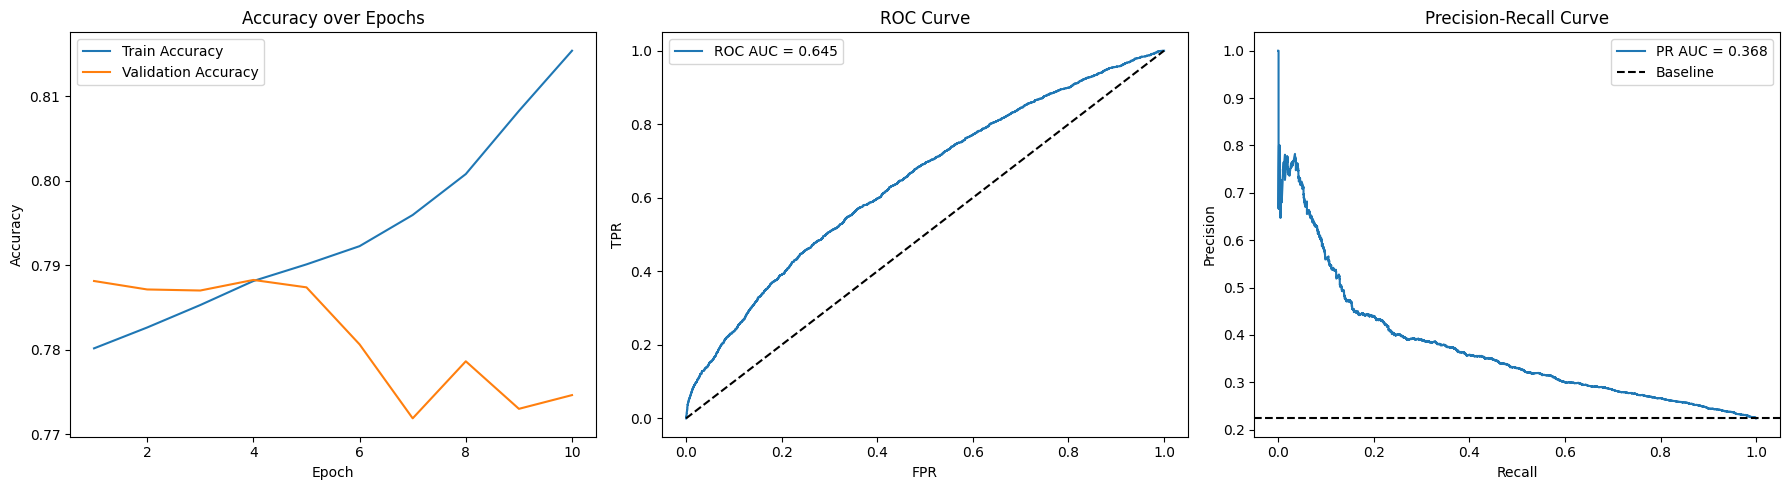

Model 1 — ROC AUC: 0.645 | PR AUC: 0.368


In [ ]:
# plots
y_pred_prob_m1 = model.predict(X_test_final).ravel()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_m1)
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob_m1)

roc_auc = auc(fpr, tpr)
pr_auc = auc(rec, prec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history.history['loss']) + 1)

# AUC over epochs
if 'auc' in history.history:
    axes[0].plot(epochs, history.history['auc'], label='Train AUC')
    axes[0].plot(epochs, history.history['val_auc'], label='Validation AUC')
    axes[0].set_ylabel('AUC')
    axes[0].set_title('AUC over Epochs')
else:
    axes[0].plot(epochs, history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy over Epochs')

axes[0].set_xlabel('Epoch')
axes[0].legend()

# ROC curve
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

# Precision-Recall curve
axes[2].plot(rec, prec, label=f'PR AUC = {pr_auc:.3f}')
axes[2].axhline(y_test.mean(), linestyle='--', color='k', label='Baseline')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Model 1 — ROC AUC: {roc_auc:.3f} | PR AUC: {pr_auc:.3f}")

#### Model 2: SBERT + Structured +  Class Weights

In [ ]:
# compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train)

class_weights = {0: class_weights[0], 1: class_weights[1]}
class_weights

{0: np.float64(0.644433703882713), 1: np.float64(2.230897936419409)}

In [ ]:
# train model
history = model.fit(
    X_train_final, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    class_weight=class_weights)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7402 - loss: 0.5348 - val_accuracy: 0.6329 - val_loss: 0.6634
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7576 - loss: 0.5005 - val_accuracy: 0.6313 - val_loss: 0.6810
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7698 - loss: 0.4745 - val_accuracy: 0.6789 - val_loss: 0.6517
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7825 - loss: 0.4494 - val_accuracy: 0.6329 - val_loss: 0.7260
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8001 - loss: 0.4243 - val_accuracy: 0.6525 - val_loss: 0.7128
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8106 - loss: 0.4009 - val_accuracy: 0.6911 - val_loss: 0.7008
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8256 - loss: 0.3776 - val_accuracy: 0.6492 - val_loss: 0.7710
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8367 - loss: 0.3536 - 

In [ ]:
# predict on test set
y_pred_prob = model.predict(X_test_final)
y_pred = (y_pred_prob > 0.5).astype(int)

# classification report
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.82      0.70      0.75      7759
           1       0.31      0.47      0.37      2241

    accuracy                           0.65     10000
   macro avg       0.56      0.58      0.56     10000
weighted avg       0.71      0.65      0.67     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


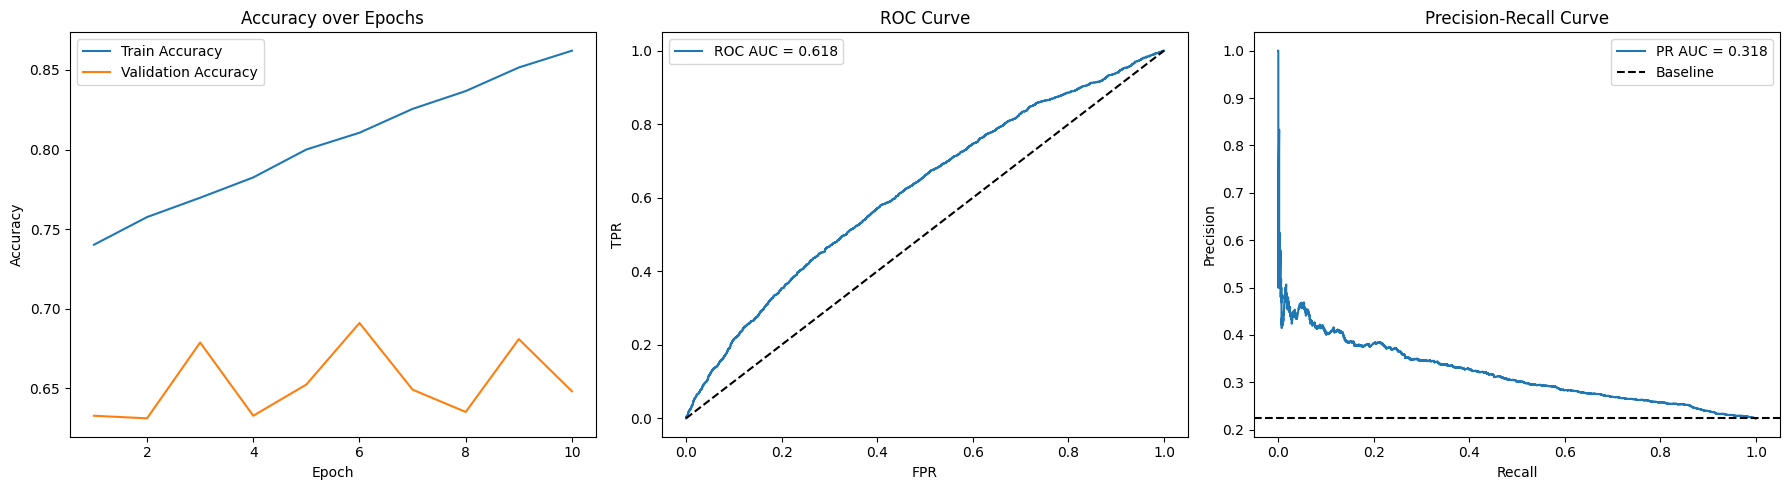

Model 2 — ROC AUC: 0.618 | PR AUC: 0.318


In [ ]:
# plots
y_pred_prob_m2 = model.predict(X_test_final).ravel()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_m2)
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob_m2)

roc_auc = auc(fpr, tpr)
pr_auc = auc(rec, prec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history.history['loss']) + 1)

# AUC over epochs curve
if 'auc' in history.history:
    axes[0].plot(epochs, history.history['auc'], label='Train AUC')
    axes[0].plot(epochs, history.history['val_auc'], label='Validation AUC')
    axes[0].set_ylabel('AUC')
    axes[0].set_title('AUC over Epochs')
else:
    axes[0].plot(epochs, history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy over Epochs')

axes[0].set_xlabel('Epoch')
axes[0].legend()

# ROC curve
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

# Precision-Recall curve
axes[2].plot(rec, prec, label=f'PR AUC = {pr_auc:.3f}')
axes[2].axhline(y_test.mean(), linestyle='--', color='k', label='Baseline')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Model 2 — ROC AUC: {roc_auc:.3f} | PR AUC: {pr_auc:.3f}")

### Functional

#### Model 3: SBERT + Structured + Multimodal


In [ ]:
# build model
# structured input
input_struct = layers.Input(shape=(X_struct_train.shape[1],))
x1 = layers.Dense(64, activation='relu')(input_struct)
x1 = layers.Dropout(0.3)(x1)

# text input (embeddings)
input_text = layers.Input(shape=(X_text_train_emb.shape[1],))
x2 = layers.Dense(128, activation='relu')(input_text)
x2 = layers.Dropout(0.3)(x2)

# combine
combined = layers.concatenate([x1, x2])

# final layers
x = layers.Dense(64, activation='relu')(combined)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=[input_struct, input_text], outputs=output)

In [ ]:
# compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

In [ ]:
# train model
history = model.fit(
    [X_struct_train, X_text_train_emb], y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6096 - auc: 0.6331 - loss: 0.6691 - val_accuracy: 0.6292 - val_auc: 0.6779 - val_loss: 0.6566
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6398 - auc: 0.6708 - loss: 0.6484 - val_accuracy: 0.6729 - val_auc: 0.6828 - val_loss: 0.6310
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6465 - auc: 0.6795 - loss: 0.6435 - val_accuracy: 0.6840 - val_auc: 0.6864 - val_loss: 0.6155
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6549 - auc: 0.6852 - loss: 0.6397 - val_accuracy: 0.6967 - val_auc: 0.6779 - val_loss: 0.6030
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6507 - auc: 0.6909 - loss: 0.6361 - val_accuracy: 0.6406 - val_auc: 0.6874 - val_loss: 0.6520
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6573 - auc: 0.6975 - loss: 0.6317 - val_accuracy: 0.6434 - val_auc: 0.6848 - val_loss: 0.6469
Epoch 7/20
1000/1000 ━━━━━━━

In [ ]:
# predict on test set
y_pred_prob = model.predict([X_struct_test, X_text_test_emb])
y_pred = (y_pred_prob > 0.5).astype(int)

# classification report
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.84      0.68      0.75      7759
           1       0.34      0.56      0.42      2241

    accuracy                           0.65     10000
   macro avg       0.59      0.62      0.59     10000
weighted avg       0.73      0.65      0.68     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


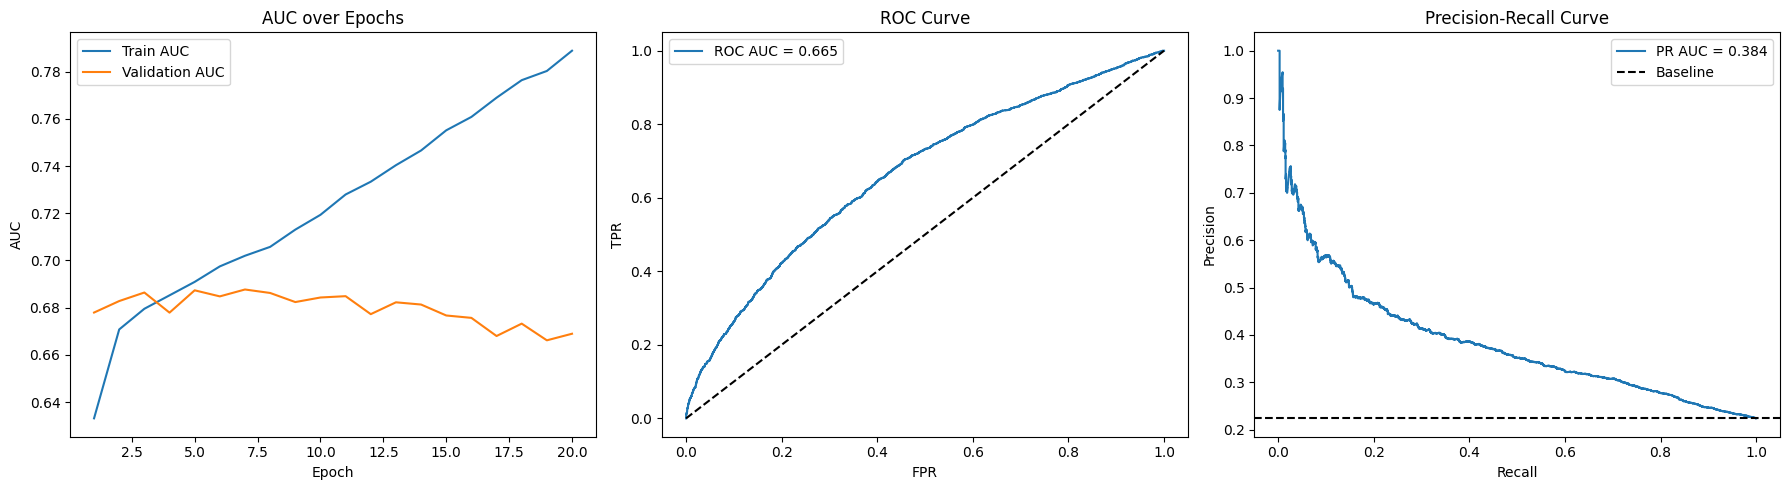

Model 3 — ROC AUC: 0.665 | PR AUC: 0.384


In [ ]:
# plots
y_pred_prob = model.predict([X_struct_test, X_text_test_emb]).ravel()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)
pr_auc = auc(rec, prec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history.history['loss']) + 1)

# AUC over epochs curve
if 'auc' in history.history:
    axes[0].plot(epochs, history.history['auc'], label='Train AUC')
    axes[0].plot(epochs, history.history['val_auc'], label='Validation AUC')
    axes[0].set_ylabel('AUC')
    axes[0].set_title('AUC over Epochs')
else:
    axes[0].plot(epochs, history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy over Epochs')

axes[0].set_xlabel('Epoch')
axes[0].legend()

# ROC curve
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

# Precision-Recall curve
axes[2].plot(rec, prec, label=f'PR AUC = {pr_auc:.3f}')
axes[2].axhline(y_test.mean(), linestyle='--', color='k', label='Baseline')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Model 3 — ROC AUC: {roc_auc:.3f} | PR AUC: {pr_auc:.3f}")

#### Model 4: SBERT + Structured + Multimodal + Dropout + BatchNorm

In [ ]:
# build model
# structured branch
input_struct = layers.Input(shape=(X_struct_train.shape[1],))
x1 = layers.Dense(64, activation='relu')(input_struct)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Dropout(0.4)(x1)

# text branch
input_text = layers.Input(shape=(X_text_train_emb.shape[1],))
x2 = layers.Dense(128, activation='relu')(input_text)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.4)(x2)

# combine
combined = layers.concatenate([x1, x2])

# final layers
x = layers.Dense(64, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=[input_struct, input_text], outputs=output)

In [ ]:
# compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

In [ ]:
# train model
history = model.fit(
    [X_struct_train, X_text_train_emb], y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5650 - auc: 0.5920 - loss: 0.7438 - val_accuracy: 0.6185 - val_auc: 0.6722 - val_loss: 0.6550
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6131 - auc: 0.6552 - loss: 0.6569 - val_accuracy: 0.6240 - val_auc: 0.6830 - val_loss: 0.6563
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6279 - auc: 0.6692 - loss: 0.6491 - val_accuracy: 0.6388 - val_auc: 0.6834 - val_loss: 0.6425
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6344 - auc: 0.6766 - loss: 0.6447 - val_accuracy: 0.6298 - val_auc: 0.6840 - val_loss: 0.6517
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6423 - auc: 0.6822 - loss: 0.6409 - val_accuracy: 0.6649 - val_auc: 0.6836 - val_loss: 0.6235
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6425 - auc: 0.6868 - loss: 0.6391 - val_accuracy: 0.6151 - val_auc: 0.6855 - val_loss: 0.6617
Epoch 7/20
1000/1000 ━━━━━━━

In [ ]:
# predict on test set
y_pred_prob = model.predict([X_struct_test, X_text_test_emb])
y_pred = (y_pred_prob > 0.5).astype(int)

# classification repor
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.85      0.63      0.72      7759
           1       0.32      0.62      0.42      2241

    accuracy                           0.62     10000
   macro avg       0.59      0.62      0.57     10000
weighted avg       0.73      0.62      0.66     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


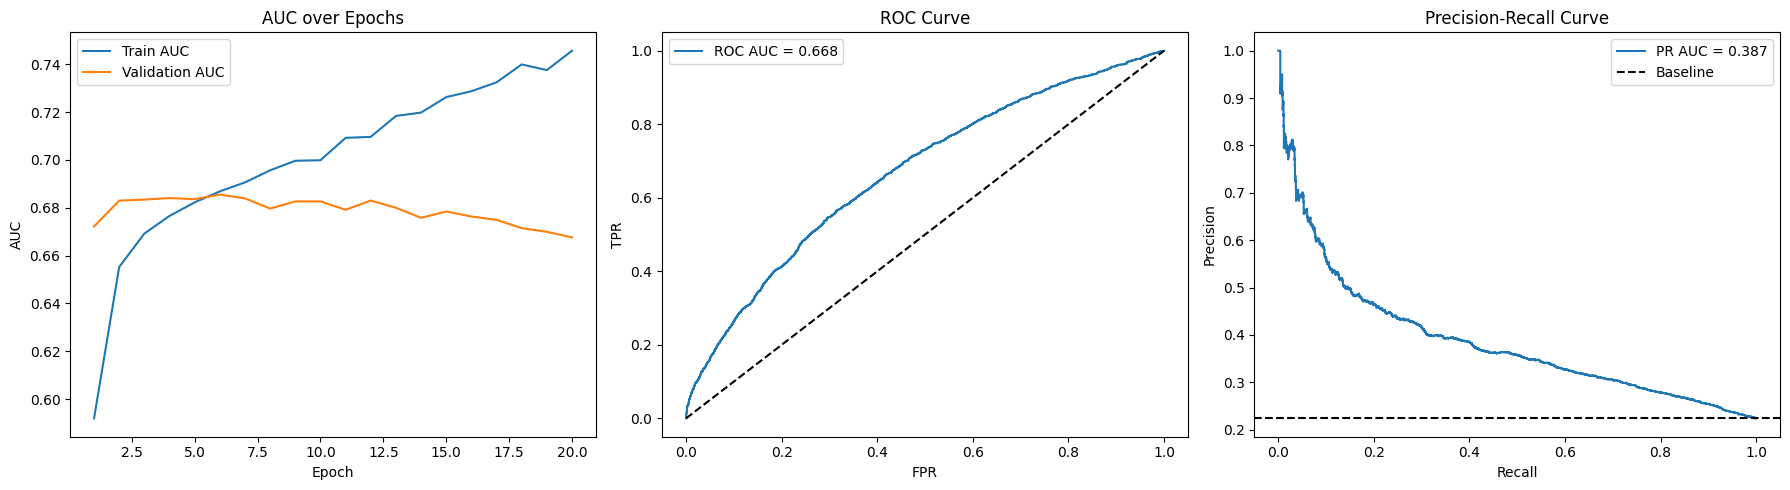

Model 4 — ROC AUC: 0.668 | PR AUC: 0.387


In [ ]:
# plots
y_pred_prob_m4 = model.predict([X_struct_test, X_text_test_emb]).ravel()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_m4)
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob_m4)

roc_auc = auc(fpr, tpr)
pr_auc = auc(rec, prec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history.history['loss']) + 1)

# AUC over epochs curve
axes[0].plot(epochs, history.history['auc'], label='Train AUC')
axes[0].plot(epochs, history.history['val_auc'], label='Validation AUC')
axes[0].set_title('AUC over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()

# ROC curve
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

# Precision-Recall curve
axes[2].plot(rec, prec, label=f'PR AUC = {pr_auc:.3f}')
axes[2].axhline(y_test.mean(), linestyle='--', color='k', label='Baseline')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Model 4 — ROC AUC: {roc_auc:.3f} | PR AUC: {pr_auc:.3f}")

#### Model 5: SBERT + Structured + Multimodal + Dropout + BatchNorm + Checkpoint + LR Scheduler

In [ ]:
# callbacks
checkpoint = ModelCheckpoint(
    "best_sbert_multimodal.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1)

In [ ]:
# structured branch
input_struct = layers.Input(shape=(X_struct_train.shape[1],), name='structured_input')
x1 = layers.Dense(64, activation='relu')(input_struct)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Dropout(0.3)(x1)

# text embedding branch
input_text = layers.Input(shape=(X_text_train_emb.shape[1],), name='text_input')
x2 = layers.Dense(128, activation='relu')(input_text)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)

# combine branches
combined = layers.concatenate([x1, x2])

# classifier head
x = layers.Dense(64, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model_bn = models.Model(inputs=[input_struct, input_text], outputs=output)

In [ ]:
# compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

In [ ]:
# train model
history = model.fit(
    [X_struct_train, X_text_train_emb], y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint, lr_scheduler])

Epoch 1/20
 995/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6720 - auc: 0.7511 - loss: 0.5919
Epoch 1: val_auc improved from None to 0.67070, saving model to best_sbert_multimodal.keras

Epoch 1: finished saving model to best_sbert_multimodal.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6722 - auc: 0.7469 - loss: 0.5943 - val_accuracy: 0.6065 - val_auc: 0.6707 - val_loss: 0.6562 - learning_rate: 0.0010
Epoch 2/20
 994/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6851 - auc: 0.7624 - loss: 0.5771
Epoch 2: val_auc did not improve from 0.67070
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6774 - auc: 0.7529 - loss: 0.5894 - val_accuracy: 0.5974 - val_auc: 0.6636 - val_loss: 0.6709 - learning_rate: 0.0010
Epoch 3/20
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6821 - auc: 0.7676 - loss: 0.5785
Epoch 3: val_auc did not improve from 0.67070

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1000/1000 ━━━━━━━━━━

In [ ]:
# load best model
model = load_model("best_sbert_multimodal.keras")

In [ ]:
# predict on test set
y_pred_prob = model.predict([X_struct_test, X_text_test_emb])
y_pred = (y_pred_prob > 0.5).astype(int)

# classification report
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.85      0.60      0.70      7759
           1       0.32      0.64      0.42      2241

    accuracy                           0.61     10000
   macro avg       0.58      0.62      0.56     10000
weighted avg       0.73      0.61      0.64     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


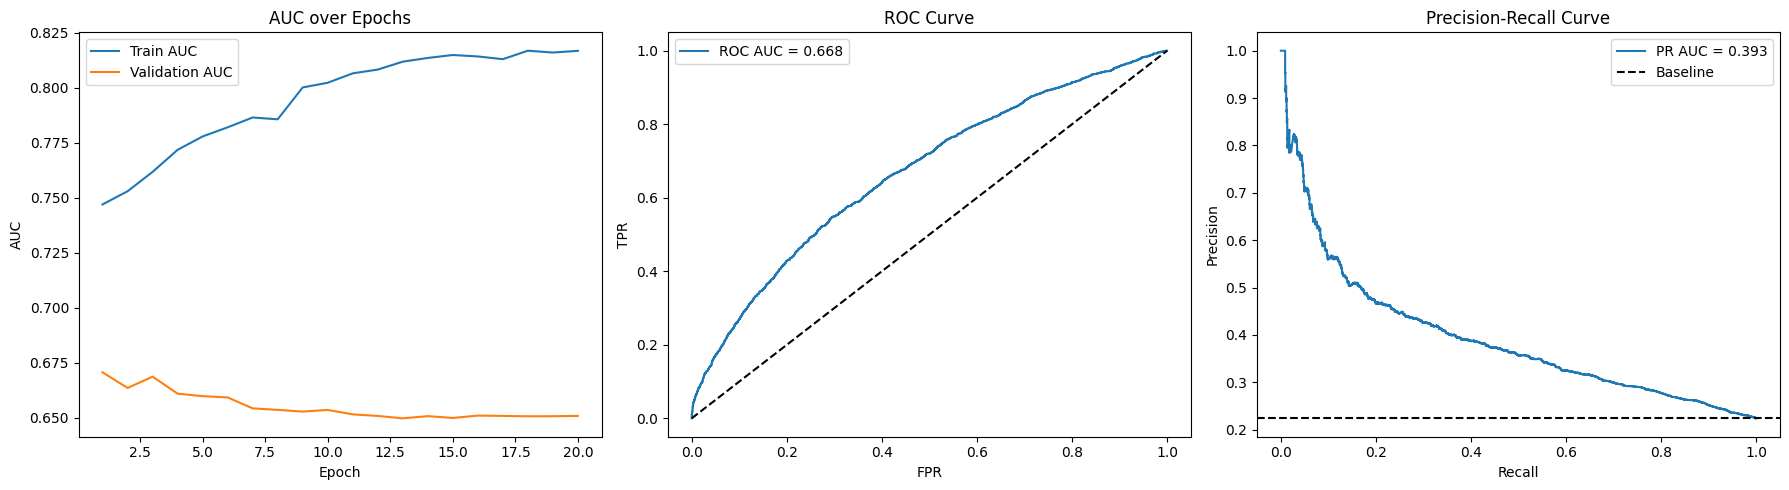

Model 5 — ROC AUC: 0.668 | PR AUC: 0.393


In [ ]:
# plots
# load best model
best_model_5 = load_model("best_sbert_multimodal.keras")

y_pred_prob_m5 = best_model_5.predict([X_struct_test, X_text_test_emb]).ravel()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_m5)
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob_m5)

roc_auc = auc(fpr, tpr)
pr_auc = auc(rec, prec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history.history['loss']) + 1)

# AUC over epochs curve
axes[0].plot(epochs, history.history['auc'], label='Train AUC')
axes[0].plot(epochs, history.history['val_auc'], label='Validation AUC')
axes[0].set_title('AUC over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()

# ROC curve
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

# Precision-Recall curve
axes[2].plot(rec, prec, label=f'PR AUC = {pr_auc:.3f}')
axes[2].axhline(y_test.mean(), linestyle='--', color='k', label='Baseline')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Model 5 — ROC AUC: {roc_auc:.3f} | PR AUC: {pr_auc:.3f}")

#### Model 6: SBERT + Chunking + Attention + Multimodal

In [ ]:
# split each discharge note into fixed-size chunks
def split_into_chunks(text, chunk_size=1200, max_chunks=5):
    text = str(text)
    chunks = [text[i:i + chunk_size] for i in range(0, len(text), chunk_size)]
    return chunks[:max_chunks]

In [ ]:
# create chunks for train and test notes
X_text_train_chunks = [split_into_chunks(text) for text in X_text_train]
X_text_test_chunks = [split_into_chunks(text) for text in X_text_test]

In [ ]:
# convert chunked text into SBERT embeddings (samples × chunks × 384)
def embed_chunked_notes(chunked_texts, max_chunks=5, embedding_dim=384):
    all_embeddings = []
    for chunks in chunked_texts:
        emb = model_sbert.encode(chunks, show_progress_bar=False)

        # pad if fewer chunks
        if len(emb) < max_chunks:
            pad = np.zeros((max_chunks - len(emb), embedding_dim))
            emb = np.vstack([emb, pad])

        all_embeddings.append(emb[:max_chunks])

    return np.array(all_embeddings)

# generate embeddings
X_text_train_chunks_emb = embed_chunked_notes(X_text_train_chunks)
X_text_test_chunks_emb = embed_chunked_notes(X_text_test_chunks)

# check shape
print(X_text_train_chunks_emb.shape)

(40000, 5, 384)


In [ ]:
# build model
# text chunk input: 5 chunks × 384 embedding dimensions
input_text = layers.Input(shape=(X_text_train_chunks_emb.shape[1], X_text_train_chunks_emb.shape[2]), name='text_chunks_input')

# attention over chunks
attention_output = layers.MultiHeadAttention(num_heads=2, key_dim=64)(input_text, input_text)

# pool attended chunk representations
text_vector = layers.GlobalAveragePooling1D()(attention_output)

# text branch
text_vector = layers.Dense(128, activation='relu')(text_vector)
text_vector = layers.Dropout(0.3)(text_vector)

# structured input
input_struct = layers.Input(shape=(X_struct_train.shape[1],), name='structured_input')

# structured branch
struct_vector = layers.Dense(64, activation='relu')(input_struct)
struct_vector = layers.Dropout(0.3)(struct_vector)

# combine text and structured branches
combined = layers.concatenate([text_vector, struct_vector])

# classifier head
x = layers.Dense(64, activation='relu')(combined)
x = layers.Dropout(0.3)(x)

output = layers.Dense(1, activation='sigmoid')(x)

attention_model = models.Model(inputs=[input_text, input_struct], outputs=output)

In [ ]:
# compile model
attention_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

In [ ]:
# callbacks

attention_checkpoint = ModelCheckpoint(
    "best_attention_sbert_model.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1)

attention_lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1)

In [ ]:
# train model
attention_history = attention_model.fit(
    [X_text_train_chunks_emb, X_struct_train], y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[attention_checkpoint, attention_lr_scheduler])

Epoch 1/20
 989/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5847 - auc: 0.5943 - loss: 0.6853
Epoch 1: val_auc improved from None to 0.68108, saving model to best_attention_sbert_model.keras

Epoch 1: finished saving model to best_attention_sbert_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6155 - auc: 0.6301 - loss: 0.6690 - val_accuracy: 0.6329 - val_auc: 0.6811 - val_loss: 0.6613 - learning_rate: 0.0010
Epoch 2/20
 987/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6374 - auc: 0.6685 - loss: 0.6564
Epoch 2: val_auc improved from 0.68108 to 0.68400, saving model to best_attention_sbert_model.keras

Epoch 2: finished saving model to best_attention_sbert_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6464 - auc: 0.6721 - loss: 0.6489 - val_accuracy: 0.7191 - val_auc: 0.6840 - val_loss: 0.6130 - learning_rate: 0.0010
Epoch 3/20
 996/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6636 - auc: 0.6822 - loss: 0.6391
Epoch 3: v

In [ ]:
# load best mode
attention_model = load_model("best_attention_sbert_model.keras")

# predict on test set
y_pred_prob = attention_model.predict([X_text_test_chunks_emb, X_struct_test])
y_pred = (y_pred_prob > 0.5).astype(int)

# classification report
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.85      0.71      0.77      7759
           1       0.35      0.55      0.43      2241

    accuracy                           0.67     10000
   macro avg       0.60      0.63      0.60     10000
weighted avg       0.74      0.67      0.69     10000



In [ ]:
# load best attention model
attention_model = load_model("best_attention_sbert_model.keras")

In [ ]:
# predict on test set
y_pred_prob = attention_model.predict([X_text_test_chunks_emb, X_struct_test])
y_pred = (y_pred_prob > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.71      0.77      7759
           1       0.35      0.55      0.43      2241

    accuracy                           0.67     10000
   macro avg       0.60      0.63      0.60     10000
weighted avg       0.74      0.67      0.69     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


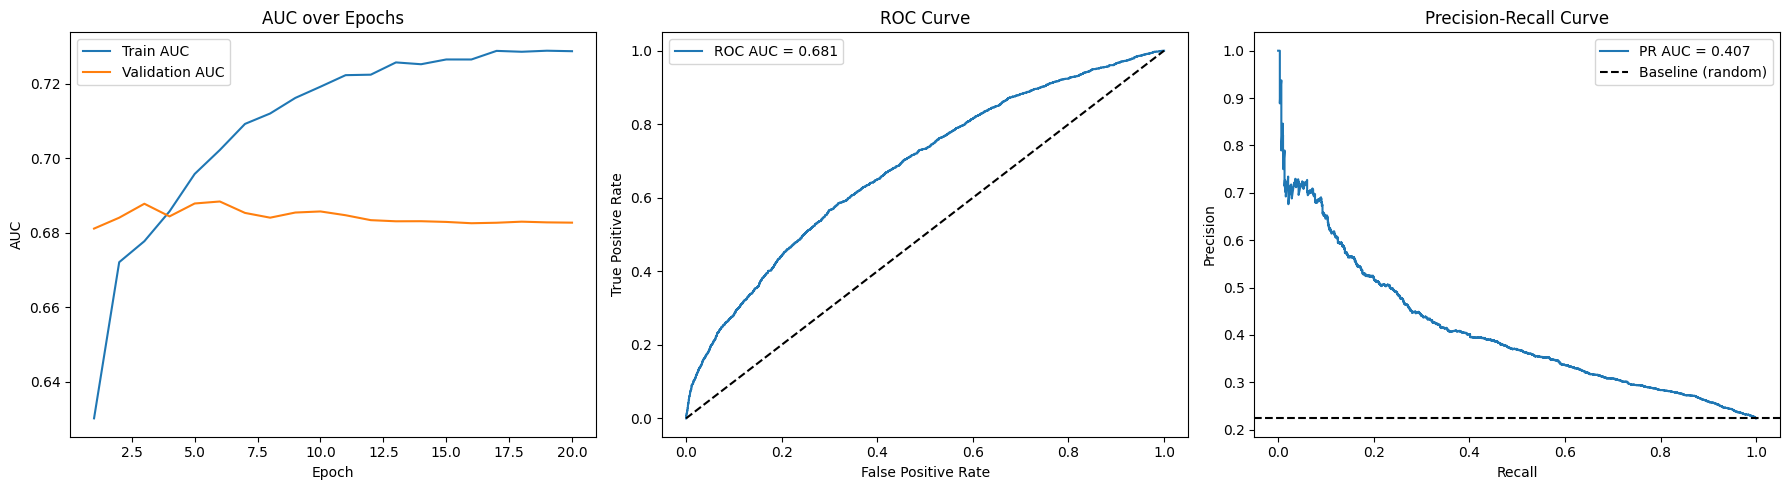

Model 6 — ROC AUC 0.681 | PR AUC 0.407


In [ ]:
# plots
y_pred_prob_att = attention_model.predict([X_text_test_chunks_emb, X_struct_test]).ravel()

fpr_att, tpr_att, _ = roc_curve(y_test, y_pred_prob_att)
prec_att, rec_att, _ = precision_recall_curve(y_test, y_pred_prob_att)

roc_auc_att = auc(fpr_att, tpr_att)
pr_auc_att = auc(rec_att, prec_att)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AUC over epochs curve
ep_att = range(1, len(attention_history.history['auc']) + 1)

axes[0].plot(ep_att, attention_history.history['auc'], label='Train AUC')
axes[0].plot(ep_att, attention_history.history['val_auc'], label='Validation AUC')
axes[0].set_title('AUC over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()

# ROC curve
axes[1].plot(fpr_att, tpr_att, label=f'ROC AUC = {roc_auc_att:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Precision-Recall curve
axes[2].plot(rec_att, prec_att, label=f'PR AUC = {pr_auc_att:.3f}')
axes[2].axhline(y_test.mean(), color='k', linestyle='--', label='Baseline (random)')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Model 6 — ROC AUC {roc_auc_att:.3f} | PR AUC {pr_auc_att:.3f}')

#### Model 7: SBERT + Chunking + Attention + BatchNorm + Dropout

In [ ]:
# build model
# text chunk input
input_text = layers.Input(
    shape=(X_text_train_chunks_emb.shape[1], X_text_train_chunks_emb.shape[2]),
    name='text_chunks_input')

# attention over SBERT chunks
attention_output = layers.MultiHeadAttention(num_heads=2, key_dim=64)(
    input_text, input_text)

# pool attended chunks
text_vector = layers.GlobalAveragePooling1D()(attention_output)

# text branch
text_vector = layers.Dense(128, activation='relu')(text_vector)
text_vector = layers.BatchNormalization()(text_vector)
text_vector = layers.Dropout(0.3)(text_vector)

# structured input
input_struct = layers.Input(
    shape=(X_struct_train.shape[1],),
    name='structured_input')

# structured branch
struct_vector = layers.Dense(64, activation='relu')(input_struct)
struct_vector = layers.BatchNormalization()(struct_vector)
struct_vector = layers.Dropout(0.3)(struct_vector)

# combine branches
combined = layers.concatenate([text_vector, struct_vector])

# final classifier
x = layers.Dense(64, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(1, activation='sigmoid')(x)

attention_bn_model = models.Model(
    inputs=[input_text, input_struct],
    outputs=output)

In [ ]:
# compile model
attention_bn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

In [ ]:
# train model
attention_bn_history = attention_bn_model.fit(
    [X_text_train_chunks_emb, X_struct_train], y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5760 - auc: 0.6090 - loss: 0.7107 - val_accuracy: 0.6386 - val_auc: 0.6688 - val_loss: 0.6424
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6299 - auc: 0.6650 - loss: 0.6531 - val_accuracy: 0.6605 - val_auc: 0.6798 - val_loss: 0.6429
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6430 - auc: 0.6772 - loss: 0.6457 - val_accuracy: 0.6029 - val_auc: 0.6849 - val_loss: 0.6580
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6430 - auc: 0.6833 - loss: 0.6409 - val_accuracy: 0.6413 - val_auc: 0.6862 - val_loss: 0.6405
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6464 - auc: 0.6877 - loss: 0.6389 - val_accuracy: 0.6205 - val_auc: 0.6843 - val_loss: 0.6507
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6473 - auc: 0.6918 - loss: 0.6362 - val_accuracy: 0.5891 - val_auc: 0.6824 - val_loss: 0.6692
Epoch 7/20
1000/1000 ━━━━━━

In [ ]:
# predict on test set
y_pred_prob_bn = attention_bn_model.predict([X_text_test_chunks_emb, X_struct_test])
y_pred_bn = (y_pred_prob_bn > 0.5).astype(int)

# classification report
print(classification_report(y_test, y_pred_bn))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.85      0.59      0.70      7759
           1       0.31      0.63      0.41      2241

    accuracy                           0.60     10000
   macro avg       0.58      0.61      0.55     10000
weighted avg       0.73      0.60      0.63     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


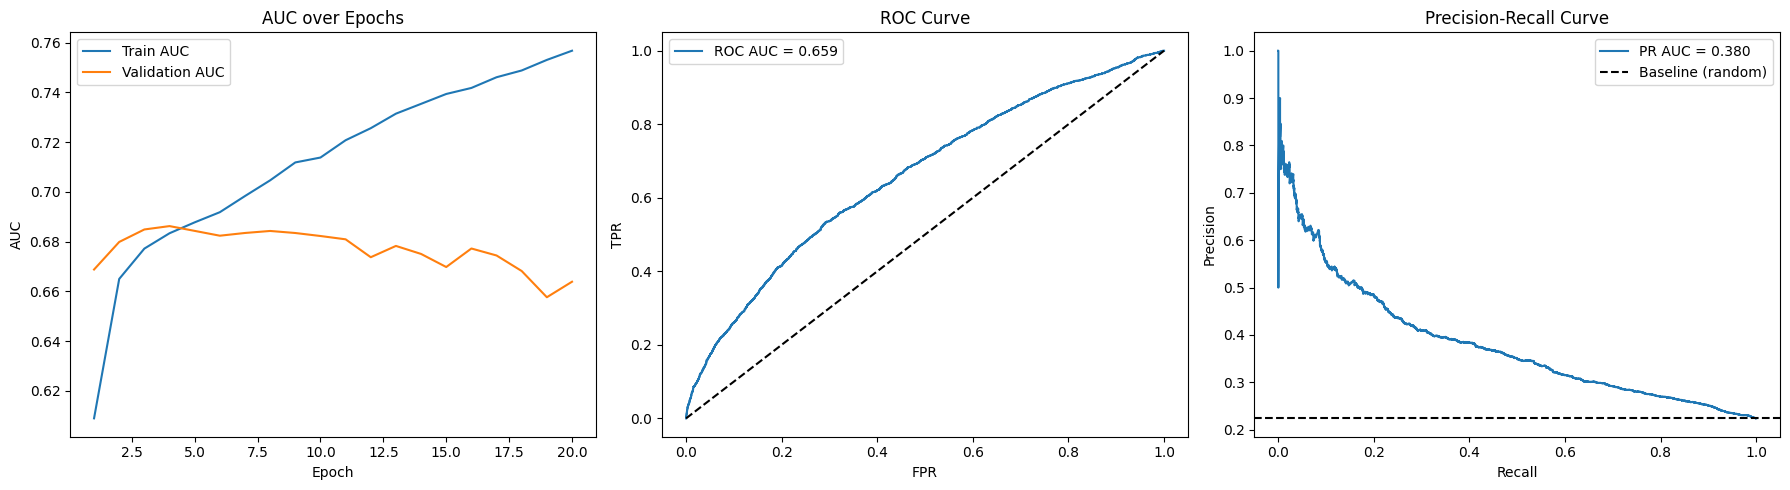

Model 7 — AUC ROC 0.659 | AUC PR 0.380


In [ ]:
# plots
y_pred_prob_bn = attention_bn_model.predict([X_text_test_chunks_emb, X_struct_test]).ravel()

fpr_bn, tpr_bn, _ = roc_curve(y_test, y_pred_prob_bn)
prec_bn, rec_bn, _ = precision_recall_curve(y_test, y_pred_prob_bn)

roc_auc_bn = auc(fpr_bn, tpr_bn)
pr_auc_bn = auc(rec_bn, prec_bn)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AUC over epochs curve
ep_bn = range(1, len(attention_bn_history.history['auc']) + 1)

axes[0].plot(ep_bn, attention_bn_history.history['auc'], label='Train AUC')
axes[0].plot(ep_bn, attention_bn_history.history['val_auc'], label='Validation AUC')
axes[0].set_title('AUC over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()

# ROC curve
axes[1].plot(fpr_bn, tpr_bn, label=f'ROC AUC = {roc_auc_bn:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

# Precision-Recall curve
axes[2].plot(rec_bn, prec_bn, label=f'PR AUC = {pr_auc_bn:.3f}')
axes[2].axhline(y_test.mean(), color='k', linestyle='--', label='Baseline (random)')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Model 7 — AUC ROC {roc_auc_bn:.3f} | AUC PR {pr_auc_bn:.3f}')

#### Model 8: SBERT + Chunking + Attention + BatchNorm + Dropout + Checkpoint + LR Scheduler

In [ ]:
# build model
input_text = layers.Input(
    shape=(X_text_train_chunks_emb.shape[1], X_text_train_chunks_emb.shape[2]),
    name='text_chunks_input')

attention_output = layers.MultiHeadAttention(num_heads=2, key_dim=64)(
    input_text, input_text)

text_vector = layers.GlobalAveragePooling1D()(attention_output)

text_vector = layers.Dense(128, activation='relu')(text_vector)
text_vector = layers.BatchNormalization()(text_vector)
text_vector = layers.Dropout(0.3)(text_vector)

input_struct = layers.Input(
    shape=(X_struct_train.shape[1],),
    name='structured_input')

struct_vector = layers.Dense(64, activation='relu')(input_struct)
struct_vector = layers.BatchNormalization()(struct_vector)
struct_vector = layers.Dropout(0.3)(struct_vector)

combined = layers.concatenate([text_vector, struct_vector])

x = layers.Dense(64, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(1, activation='sigmoid')(x)

attention_bn_final_model = models.Model(
    inputs=[input_text, input_struct],
    outputs=output)

In [ ]:
# compile model
attention_bn_final_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

In [ ]:
# callbacks
attention_bn_final_checkpoint = ModelCheckpoint(
    "best_attention_bn_final_model.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1)

attention_bn_final_lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1)

In [ ]:
# train model
attention_bn_final_history = attention_bn_final_model.fit(
    [X_text_train_chunks_emb, X_struct_train], y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[attention_bn_final_checkpoint, attention_bn_final_lr_scheduler])

Epoch 1/20
 987/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5569 - auc: 0.5931 - loss: 0.7597
Epoch 1: val_auc improved from None to 0.66918, saving model to best_attention_bn_final_model.keras

Epoch 1: finished saving model to best_attention_bn_final_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5776 - auc: 0.6082 - loss: 0.7126 - val_accuracy: 0.5505 - val_auc: 0.6692 - val_loss: 0.7004 - learning_rate: 0.0010
Epoch 2/20
 985/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6199 - auc: 0.6561 - loss: 0.6558
Epoch 2: val_auc improved from 0.66918 to 0.68167, saving model to best_attention_bn_final_model.keras

Epoch 2: finished saving model to best_attention_bn_final_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6222 - auc: 0.6584 - loss: 0.6555 - val_accuracy: 0.6442 - val_auc: 0.6817 - val_loss: 0.6475 - learning_rate: 0.0010
Epoch 3/20
 998/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6415 - auc: 0.6784 - loss: 0.647

In [ ]:
# load best model
attention_bn_final_model = load_model("best_attention_bn_final_model.keras")

# predict on test set
y_pred_prob_bn_final = attention_bn_final_model.predict([X_text_test_chunks_emb, X_struct_test])
y_pred_bn_final = (y_pred_prob_bn_final > 0.5).astype(int)

# classification report
print(classification_report(y_test, y_pred_bn_final))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      7759
           1       0.38      0.48      0.42      2241

    accuracy                           0.71     10000
   macro avg       0.61      0.62      0.61     10000
weighted avg       0.73      0.71      0.72     10000



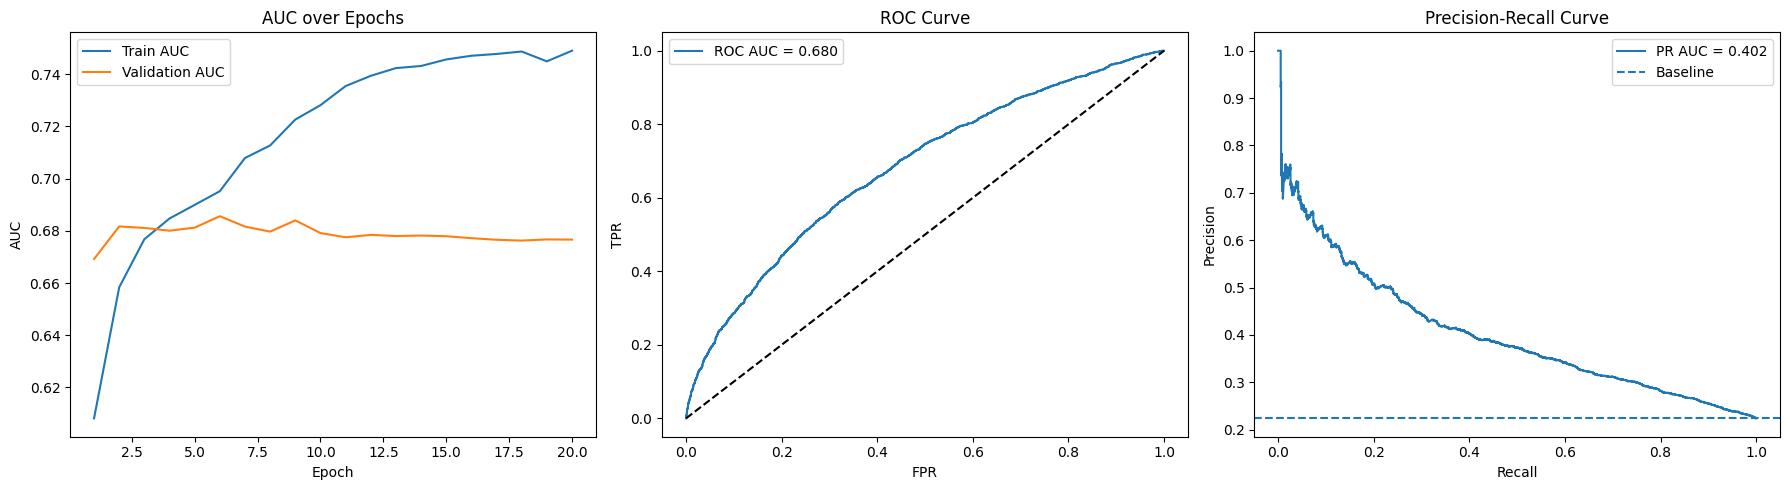

Model 8 — ROC AUC: 0.680 | PR AUC: 0.402


In [ ]:
# plots
y_pred_prob_bn_final = y_pred_prob_bn_final.ravel()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_bn_final)
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob_bn_final)

roc_auc = auc(fpr, tpr)
pr_auc = auc(rec, prec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AUC over epochs curve
epochs = range(1, len(attention_bn_final_history.history['auc']) + 1)
axes[0].plot(epochs, attention_bn_final_history.history['auc'], label='Train AUC')
axes[0].plot(epochs, attention_bn_final_history.history['val_auc'], label='Validation AUC')
axes[0].set_title('AUC over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()

# ROC curve
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

# Precision-Recall curve
axes[2].plot(rec, prec, label=f'PR AUC = {pr_auc:.3f}')
axes[2].axhline(y_test.mean(), linestyle='--', label='Baseline')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Model 8 — ROC AUC: {roc_auc:.3f} | PR AUC: {pr_auc:.3f}")

## ClinicalBERT models

ClinicalBERT (`emilyalsentzer/Bio_ClinicalBERT`) is a domain-adapted BERT model fine-tuned on MIMIC-III discharge summaries, the same data domain as our cohort. Replacing SBERT with ClinicalBERT tests a clear hypothesis: that domain-pretrained embeddings will encode clinically meaningful concepts (medications, conditions, procedures, social determinants) more effectively than a general-purpose encoder.

We test four variants progressively, each addressing a specific limitation of the previous one:

- **V1 (50k sample, mean pool):** baseline replacement of SBERT with ClinicalBERT in the team's existing pipeline
- **V2 (full data, attention):** scales to the full ~94k cohort and introduces dual-input architecture with multi-head attention on the text branch
- **V3 (rich pooling):** concatenates [CLS], mean-pooled, and max-pooled token representations to reduce information loss from pooling
- **V4 (chunked encoding):** splits notes into overlapping 512-token windows to capture content from longer notes that would otherwise be truncated

To support reproducibility and fast iteration, we embed the entire ~94k cohort once and persist the embeddings to GCS. Subsequent runs load from cache, allowing model architecture changes to be tested in minutes rather than hours.

In [ ]:
# create an index-reset copy of df so embedding[i] aligns with df_full.iloc[i]
df_full = df.reset_index(drop=True).copy()
print('df_full shape:', df_full.shape)

df_full shape: (272842, 55)


In [ ]:
CBERT_MODEL = 'emilyalsentzer/Bio_ClinicalBERT'
tokenizer_cbert = AutoTokenizer.from_pretrained(CBERT_MODEL)
model_cbert     = AutoModel.from_pretrained(CBERT_MODEL)
model_cbert.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cbert = model_cbert.to(device)
print('Using device:', device)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Using device: cuda


In [ ]:
# embedding functions used to get 1. regular embeddings 2. rich embeddings 3. chunk embeddings
def mean_pool(token_embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * mask, dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)


def get_clinicalbert_embeddings(texts, batch_size=32, max_length=512):
    """Mean-pooled embeddings → (N, 768)"""
    all_emb = []
    for start in range(0, len(texts), batch_size):
        batch   = texts[start : start + batch_size]
        encoded = tokenizer_cbert(batch, padding=True, truncation=True,
                                   max_length=max_length, return_tensors='pt').to(device)
        with torch.no_grad():
            out = model_cbert(**encoded)
        emb = mean_pool(out.last_hidden_state, encoded['attention_mask'])
        all_emb.append(emb.cpu().numpy())
        if (start // batch_size) % 50 == 0:
            print(f'  {min(start + batch_size, len(texts))} / {len(texts)}')
    return np.vstack(all_emb)


def get_clinicalbert_embeddings_rich(texts, batch_size=32, max_length=512):
    """CLS + mean pool + max pool concatenated → (N, 2304)"""
    all_emb = []
    for start in range(0, len(texts), batch_size):
        batch   = texts[start : start + batch_size]
        encoded = tokenizer_cbert(batch, padding=True, truncation=True,
                                   max_length=max_length, return_tensors='pt').to(device)
        with torch.no_grad():
            out = model_cbert(**encoded)

        token_emb = out.last_hidden_state
        mask      = encoded['attention_mask']

        cls_emb  = token_emb[:, 0, :]
        mask_exp = mask.unsqueeze(-1).float()
        mean_emb = (token_emb * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        max_emb  = token_emb.masked_fill(mask.unsqueeze(-1) == 0, -1e9).max(dim=1).values

        rich_emb = torch.cat([cls_emb, mean_emb, max_emb], dim=1)
        all_emb.append(rich_emb.cpu().numpy())
        if (start // batch_size) % 50 == 0:
            print(f'  {min(start + batch_size, len(texts))} / {len(texts)}')
    return np.vstack(all_emb)

In [ ]:
# creating/loading the embeddings - once created we save computing time by just retrieving them
fs       = gcsfs.GCSFileSystem()
BUCKET   = 'ba865-t9-mimiciv/embeddings/clinicalbert/'

EMB_PATH       = BUCKET + 'full_embeddings.npy'
RICH_EMB_PATH  = BUCKET + 'full_embeddings_rich.npy'
CHUNK_EMB_PATH = BUCKET + 'full_embeddings_chunked.npy'

# --- mean-pool embeddings (used by V1 and V2) ---
if fs.exists(EMB_PATH):
    print('Loading mean-pool embeddings...')
    with fs.open(EMB_PATH, 'rb') as f:
        embeddings_full = np.load(f)
    print('  Loaded:', embeddings_full.shape)
else:
    print('Computing mean-pool embeddings (~20 min on T4)...')
    embeddings_full = get_clinicalbert_embeddings(df_full['discharge_text'].tolist())
    with fs.open(EMB_PATH, 'wb') as f:
        np.save(f, embeddings_full)

# --- rich embeddings (used by V3) ---
if fs.exists(RICH_EMB_PATH):
    print('Loading rich embeddings...')
    with fs.open(RICH_EMB_PATH, 'rb') as f:
        embeddings_rich = np.load(f)
    print('  Loaded:', embeddings_rich.shape)
else:
    print('Computing rich embeddings (~30 min on T4)...')
    embeddings_rich = get_clinicalbert_embeddings_rich(df_full['discharge_text'].tolist())
    with fs.open(RICH_EMB_PATH, 'wb') as f:
        np.save(f, embeddings_rich)

# --- chunked embeddings (used by V4) ---
# These take ~5h to compute, so we fail gracefully if not pre-computed
HAS_CHUNKED = fs.exists(CHUNK_EMB_PATH)
if HAS_CHUNKED:
    print('Loading chunked embeddings...')
    with fs.open(CHUNK_EMB_PATH, 'rb') as f:
        embeddings_chunked = np.load(f)
    print('  Loaded:', embeddings_chunked.shape)
else:
    print('Chunked embeddings not found on GCS — V4 section will be skipped, embedding creation takes ~ 5.5h')

# row alignment checks
assert len(embeddings_full) == len(df_full), 'mean-pool shape mismatch'
assert len(embeddings_rich) == len(df_full), 'rich shape mismatch'
if HAS_CHUNKED:
    assert len(embeddings_chunked) == len(df_full), 'chunked shape mismatch'
print('\nAll alignment checks passed.')

Loading mean-pool embeddings...
  Loaded: (272842, 768)
Loading rich embeddings...
  Loaded: (272842, 2304)
Loading chunked embeddings...
  Loaded: (272842, 1536)

All alignment checks passed.


### Model V1: ClinicalBERT (mean pool) on 50k sample

Direct upgrade of the team's SBERT models — same 50k sample, same dense architecture, but ClinicalBERT embeddings instead of all-MiniLM-L6-v2. Establishes the ClinicalBERT baseline.

In [ ]:
# -- 50k sample aligned with embeddings_full via reset_index --
SAMPLE_SEED = 42
df_sample_cb = df_full.sample(n=50_000, random_state=SAMPLE_SEED)
emb_sample   = embeddings_full[df_sample_cb.index]

y_cb1        = df_sample_cb['readmitted_30d'].values
X_struct_cb1 = df_sample_cb.drop(columns=['readmitted_30d', 'discharge_text', 'text_length'],
                                  errors='ignore').values

(X_struct_train_cb1, X_struct_test_cb1,
 X_emb_train_cb1,    X_emb_test_cb1,
 y_train_cb1,        y_test_cb1) = train_test_split(
    X_struct_cb1, emb_sample, y_cb1,
    test_size=0.2, random_state=SAMPLE_SEED, stratify=y_cb1
)

scaler_cb1 = StandardScaler()
X_struct_train_cb1 = scaler_cb1.fit_transform(X_struct_train_cb1)
X_struct_test_cb1  = scaler_cb1.transform(X_struct_test_cb1)

weights_cb1       = compute_class_weight(class_weight='balanced',
                                          classes=np.array([0,1]), y=y_train_cb1)
class_weights_cb1 = dict(zip([0,1], weights_cb1))

# -- simple dense model: structured + ClinicalBERT concatenated --
X_train_cb1 = np.hstack([X_struct_train_cb1, X_emb_train_cb1])
X_test_cb1  = np.hstack([X_struct_test_cb1,  X_emb_test_cb1])

model_cb1 = models.Sequential([
    layers.Input(shape=(X_train_cb1.shape[1],)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name='clinicalbert_v1')

model_cb1.compile(optimizer=Adam(learning_rate=1e-3),
                   loss='binary_crossentropy',
                   metrics=['accuracy', AUC(name='auc'), AUC(name='auc_pr', curve='PR'),
                            Precision(name='precision'), Recall(name='recall')])

history_cb1 = model_cb1.fit(
    X_train_cb1, y_train_cb1,
    validation_split=0.2, epochs=20, batch_size=64,
    class_weight=class_weights_cb1,
    callbacks=[EarlyStopping(monitor='val_auc_pr', patience=5, mode='max',
                              restore_best_weights=True, verbose=1)],
    verbose=1
)

y_prob_cb1 = model_cb1.predict(X_test_cb1, verbose=0).ravel()
fpr_cb1, tpr_cb1, _ = roc_curve(y_test_cb1, y_prob_cb1)
prec_cb1, rec_cb1, _ = precision_recall_curve(y_test_cb1, y_prob_cb1)
roc_auc_cb1, pr_auc_cb1 = auc(fpr_cb1, tpr_cb1), auc(rec_cb1, prec_cb1)

print(f'\nV1 — ROC AUC: {roc_auc_cb1:.4f}  |  PR AUC: {pr_auc_cb1:.4f}')
print(classification_report(y_test_cb1, (y_prob_cb1 > 0.5).astype(int),
                             target_names=['Not Readmitted', 'Readmitted']))

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5834 - auc: 0.6128 - auc_pr: 0.3161 - loss: 0.7574 - precision: 0.2878 - recall: 0.5771 - val_accuracy: 0.5981 - val_auc: 0.6676 - val_auc_pr: 0.3870 - val_loss: 0.7210 - val_precision: 0.3083 - val_recall: 0.6629
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6150 - auc: 0.6500 - auc_pr: 0.3665 - loss: 0.6973 - precision: 0.3128 - recall: 0.5936 - val_accuracy: 0.6066 - val_auc: 0.6784 - val_auc_pr: 0.3945 - val_loss: 0.6988 - val_precision: 0.3149 - val_recall: 0.6686
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6352 - auc: 0.6672 - auc_pr: 0.3839 - loss: 0.6804 - precision: 0.3285 - recall: 0.5943 - val_accuracy: 0.6398 - val_auc: 0.6753 - val_auc_pr: 0.3918 - val_loss: 0.6682 - val_precision: 0.3266 - val_recall: 0.5988
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6400 - auc: 0.6753 - auc_pr: 0.3866 - loss: 0.6708 - precision: 0.3348 - recall: 0.6072 - val_

### Model V2: ClinicalBERT + Full Data + Attention

Three changes from V1: (1) trained on the full ~94k dataset instead of 50k sample, (2) dual-input functional architecture with separate text and structured branches, (3) MultiHeadAttention on the text embedding (reshape 768→(12,64), 4 heads, residual, dual mean+max pooling). Label smoothing and stronger dropout added to combat overfitting on the larger dataset.

This is our best-performing ClinicalBERT model.

In [ ]:
# -- full dataset features --
y_full_cb        = df_full['readmitted_30d'].values
X_struct_full_cb = df_full.drop(columns=['readmitted_30d', 'discharge_text', 'text_length'],
                                 errors='ignore').values

(X_struct_train_cb2, X_struct_test_cb2,
 X_emb_train_cb2,    X_emb_test_cb2,
 y_train_cb2,        y_test_cb2) = train_test_split(
    X_struct_full_cb, embeddings_full, y_full_cb,
    test_size=0.2, random_state=42, stratify=y_full_cb
)

scaler_cb2 = StandardScaler()
X_struct_train_cb2 = scaler_cb2.fit_transform(X_struct_train_cb2)
X_struct_test_cb2  = scaler_cb2.transform(X_struct_test_cb2)

weights_cb2       = compute_class_weight(class_weight='balanced',
                                          classes=np.array([0,1]), y=y_train_cb2)
class_weights_cb2 = dict(zip([0,1], weights_cb2))
print('Class weights:', class_weights_cb2)

# -- dual-input attention model --
N_STRUCT_CB2 = X_struct_train_cb2.shape[1]

text_input_cb2 = layers.Input(shape=(768,), name='text_embedding')
x_text = layers.Reshape((12, 64))(text_input_cb2)
attn   = layers.MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x_text, x_text)
x_text = layers.LayerNormalization()(attn)
x_text = layers.Add()([x_text, attn])
x_mean = layers.GlobalAveragePooling1D()(x_text)
x_max  = layers.GlobalMaxPooling1D()(x_text)
x_text = layers.Concatenate()([x_mean, x_max])
x_text = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x_text)
x_text = layers.Dropout(0.4)(x_text)

struct_input_cb2 = layers.Input(shape=(N_STRUCT_CB2,), name='structured_features')
x_struct = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(struct_input_cb2)
x_struct = layers.BatchNormalization()(x_struct)
x_struct = layers.Dropout(0.3)(x_struct)
x_struct = layers.Dense(64, activation='relu')(x_struct)

merged = layers.Concatenate()([x_text, x_struct])
x      = layers.Dense(128, activation='relu')(merged)
x      = layers.BatchNormalization()(x)
x      = layers.Dropout(0.35)(x)
output = layers.Dense(1, activation='sigmoid', name='readmission')(x)

model_cb2 = models.Model([text_input_cb2, struct_input_cb2], output, name='clinicalbert_v2')

model_cb2.compile(optimizer=Adam(learning_rate=1e-3),
                   loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
                   metrics=['accuracy', AUC(name='auc'), AUC(name='auc_pr', curve='PR'),
                            Precision(name='precision'), Recall(name='recall')])

history_cb2 = model_cb2.fit(
    [X_emb_train_cb2, X_struct_train_cb2], y_train_cb2,
    validation_split=0.2, epochs=30, batch_size=128,
    class_weight=class_weights_cb2,
    callbacks=[EarlyStopping(monitor='val_auc_pr', patience=5, mode='max',
                              restore_best_weights=True, verbose=1),
                ReduceLROnPlateau(monitor='val_auc_pr', factor=0.5, patience=3,
                                   mode='max', min_lr=1e-6, verbose=1)],
    verbose=1
)

y_prob_cb2 = model_cb2.predict([X_emb_test_cb2, X_struct_test_cb2], verbose=0).ravel()
thresholds_cb2 = np.arange(0.1, 0.9, 0.05)
f1s_cb2        = [f1_score(y_test_cb2, (y_prob_cb2 > t).astype(int)) for t in thresholds_cb2]
best_t_cb2     = thresholds_cb2[np.argmax(f1s_cb2)]

fpr_cb2, tpr_cb2, _ = roc_curve(y_test_cb2, y_prob_cb2)
prec_cb2, rec_cb2, _ = precision_recall_curve(y_test_cb2, y_prob_cb2)
roc_auc_cb2, pr_auc_cb2 = auc(fpr_cb2, tpr_cb2), auc(rec_cb2, prec_cb2)

print(f'\nV2 — ROC AUC: {roc_auc_cb2:.4f}  |  PR AUC: {pr_auc_cb2:.4f}')
print(f'Best threshold: {best_t_cb2:.2f}')
print(classification_report(y_test_cb2, (y_prob_cb2 > best_t_cb2).astype(int),
                             target_names=['Not Readmitted', 'Readmitted']))

Class weights: {0: np.float64(0.6444244338814915), 1: np.float64(2.231009035528844)}
Epoch 1/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.6145 - auc: 0.6375 - auc_pr: 0.3386 - loss: 0.6946 - precision: 0.3084 - recall: 0.5790 - val_accuracy: 0.6813 - val_auc: 0.6794 - val_auc_pr: 0.3981 - val_loss: 0.6354 - val_precision: 0.3587 - val_recall: 0.5380 - learning_rate: 0.0010
Epoch 2/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6503 - auc: 0.6798 - auc_pr: 0.3951 - loss: 0.6584 - precision: 0.3410 - recall: 0.6007 - val_accuracy: 0.6374 - val_auc: 0.6893 - val_auc_pr: 0.4115 - val_loss: 0.6612 - val_precision: 0.3360 - val_recall: 0.6358 - learning_rate: 0.0010
Epoch 3/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6530 - auc: 0.6866 - auc_pr: 0.4026 - loss: 0.6506 - precision: 0.3445 - recall: 0.6069 - val_accuracy: 0.6454 - val_auc: 0.6927 - val_auc_pr: 0.4158 - val_loss: 0.6574 - val_precision: 0.3415 - val_recall: 0.6297 - learning_rate: 0.

### Model V3: Rich pooling (CLS + Mean + Max)

Replaces the single mean-pool 768d vector with a concatenation of three pooled views: the [CLS] token (768d), mean pool (768d), and max pool (768d) → 2304d total. The richer representation is projected back to 768d before the same attention block as V2, so attention capacity is matched. Tests whether more information per note translates to better predictions.

Result: did not outperform V2.

In [ ]:
(X_struct_train_cb3, X_struct_test_cb3,
 X_emb_train_cb3,    X_emb_test_cb3,
 y_train_cb3,        y_test_cb3) = train_test_split(
    X_struct_full_cb, embeddings_rich, y_full_cb,
    test_size=0.2, random_state=42, stratify=y_full_cb
)

scaler_cb3 = StandardScaler()
X_struct_train_cb3 = scaler_cb3.fit_transform(X_struct_train_cb3)
X_struct_test_cb3  = scaler_cb3.transform(X_struct_test_cb3)

weights_cb3       = compute_class_weight(class_weight='balanced',
                                          classes=np.array([0,1]), y=y_train_cb3)
class_weights_cb3 = dict(zip([0,1], weights_cb3))

# -- model with projection layer (2304 → 768) --
N_STRUCT_CB3 = X_struct_train_cb3.shape[1]

text_input_cb3 = layers.Input(shape=(2304,), name='text_embedding_rich')
x_text = layers.Dense(768, activation='relu')(text_input_cb3)   # project down
x_text = layers.Dropout(0.2)(x_text)
x_text = layers.Reshape((12, 64))(x_text)
attn   = layers.MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x_text, x_text)
x_text = layers.LayerNormalization()(attn)
x_text = layers.Add()([x_text, attn])
x_mean = layers.GlobalAveragePooling1D()(x_text)
x_max  = layers.GlobalMaxPooling1D()(x_text)
x_text = layers.Concatenate()([x_mean, x_max])
x_text = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x_text)
x_text = layers.Dropout(0.4)(x_text)

struct_input_cb3 = layers.Input(shape=(N_STRUCT_CB3,), name='structured_features_rich')
x_struct = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(struct_input_cb3)
x_struct = layers.BatchNormalization()(x_struct)
x_struct = layers.Dropout(0.3)(x_struct)
x_struct = layers.Dense(64, activation='relu')(x_struct)

merged = layers.Concatenate()([x_text, x_struct])
x      = layers.Dense(128, activation='relu')(merged)
x      = layers.BatchNormalization()(x)
x      = layers.Dropout(0.35)(x)
output = layers.Dense(1, activation='sigmoid', name='readmission')(x)

model_cb3 = models.Model([text_input_cb3, struct_input_cb3], output, name='clinicalbert_v3')

model_cb3.compile(optimizer=Adam(learning_rate=1e-3),
                   loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
                   metrics=['accuracy', AUC(name='auc'), AUC(name='auc_pr', curve='PR'),
                            Precision(name='precision'), Recall(name='recall')])

history_cb3 = model_cb3.fit(
    [X_emb_train_cb3, X_struct_train_cb3], y_train_cb3,
    validation_split=0.2, epochs=30, batch_size=128,
    class_weight=class_weights_cb3,
    callbacks=[EarlyStopping(monitor='val_auc_pr', patience=5, mode='max',
                              restore_best_weights=True, verbose=1),
                ReduceLROnPlateau(monitor='val_auc_pr', factor=0.5, patience=3,
                                   mode='max', min_lr=1e-6, verbose=1)],
    verbose=1
)

y_prob_cb3 = model_cb3.predict([X_emb_test_cb3, X_struct_test_cb3], verbose=0).ravel()
fpr_cb3, tpr_cb3, _ = roc_curve(y_test_cb3, y_prob_cb3)
prec_cb3, rec_cb3, _ = precision_recall_curve(y_test_cb3, y_prob_cb3)
roc_auc_cb3, pr_auc_cb3 = auc(fpr_cb3, tpr_cb3), auc(rec_cb3, prec_cb3)

print(f'\nV3 — ROC AUC: {roc_auc_cb3:.4f}  |  PR AUC: {pr_auc_cb3:.4f}')
print(classification_report(y_test_cb3, (y_prob_cb3 > 0.5).astype(int),
                             target_names=['Not Readmitted', 'Readmitted']))

Epoch 1/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.6153 - auc: 0.6339 - auc_pr: 0.3357 - loss: 0.6977 - precision: 0.3083 - recall: 0.5756 - val_accuracy: 0.6250 - val_auc: 0.6807 - val_auc_pr: 0.4019 - val_loss: 0.6806 - val_precision: 0.3277 - val_recall: 0.6427 - learning_rate: 0.0010
Epoch 2/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6473 - auc: 0.6747 - auc_pr: 0.3901 - loss: 0.6619 - precision: 0.3377 - recall: 0.5963 - val_accuracy: 0.6360 - val_auc: 0.6836 - val_auc_pr: 0.4042 - val_loss: 0.6577 - val_precision: 0.3331 - val_recall: 0.6253 - learning_rate: 0.0010
Epoch 3/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6539 - auc: 0.6802 - auc_pr: 0.3969 - loss: 0.6544 - precision: 0.3435 - recall: 0.5968 - val_accuracy: 0.6578 - val_auc: 0.6839 - val_auc_pr: 0.4082 - val_loss: 0.6499 - val_precision: 0.3449 - val_recall: 0.5885 - learning_rate: 0.0010
Epoch 4/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6541 - au

### Model V4: Chunked encoding (full note coverage)

ClinicalBERT has a 512-token limit; truncation discards content from the latter parts of long discharge notes (which often contain follow-up plans and discharge condition). V4 splits each note into overlapping 512-token chunks (50-token overlap), embeds each chunk separately, and aggregates with mean+max pooling across chunks → 1536d per note. Same architecture as V3 with input projection.

In [ ]:
if not HAS_CHUNKED:
    print('Skipping V4 — chunked embeddings not available.')
    print('To enable: run the chunked encoding pipeline (~5h on A100) and save to GCS.')
    roc_auc_cb4 = pr_auc_cb4 = None

else:
    (X_struct_train_cb4, X_struct_test_cb4,
     X_emb_train_cb4,    X_emb_test_cb4,
     y_train_cb4,        y_test_cb4) = train_test_split(
        X_struct_full_cb, embeddings_chunked, y_full_cb,
        test_size=0.2, random_state=42, stratify=y_full_cb
    )

    scaler_cb4 = StandardScaler()
    X_struct_train_cb4 = scaler_cb4.fit_transform(X_struct_train_cb4)
    X_struct_test_cb4  = scaler_cb4.transform(X_struct_test_cb4)

    weights_cb4       = compute_class_weight(class_weight='balanced',
                                              classes=np.array([0,1]), y=y_train_cb4)
    class_weights_cb4 = dict(zip([0,1], weights_cb4))

    N_STRUCT_CB4 = X_struct_train_cb4.shape[1]

    text_input_cb4 = layers.Input(shape=(1536,), name='text_embedding_chunked')
    x_text = layers.Dense(768, activation='relu')(text_input_cb4)
    x_text = layers.Dropout(0.2)(x_text)
    x_text = layers.Reshape((12, 64))(x_text)
    attn   = layers.MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x_text, x_text)
    x_text = layers.LayerNormalization()(attn)
    x_text = layers.Add()([x_text, attn])
    x_mean = layers.GlobalAveragePooling1D()(x_text)
    x_max  = layers.GlobalMaxPooling1D()(x_text)
    x_text = layers.Concatenate()([x_mean, x_max])
    x_text = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x_text)
    x_text = layers.Dropout(0.4)(x_text)

    struct_input_cb4 = layers.Input(shape=(N_STRUCT_CB4,), name='structured_features_chunked')
    x_struct = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(struct_input_cb4)
    x_struct = layers.BatchNormalization()(x_struct)
    x_struct = layers.Dropout(0.3)(x_struct)
    x_struct = layers.Dense(64, activation='relu')(x_struct)

    merged = layers.Concatenate()([x_text, x_struct])
    x      = layers.Dense(128, activation='relu')(merged)
    x      = layers.BatchNormalization()(x)
    x      = layers.Dropout(0.35)(x)
    output = layers.Dense(1, activation='sigmoid', name='readmission')(x)

    model_cb4 = models.Model([text_input_cb4, struct_input_cb4], output, name='clinicalbert_v4')

    model_cb4.compile(optimizer=Adam(learning_rate=1e-3),
                       loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
                       metrics=['accuracy', AUC(name='auc'), AUC(name='auc_pr', curve='PR'),
                                Precision(name='precision'), Recall(name='recall')])

    history_cb4 = model_cb4.fit(
        [X_emb_train_cb4, X_struct_train_cb4], y_train_cb4,
        validation_split=0.2, epochs=30, batch_size=128,
        class_weight=class_weights_cb4,
        callbacks=[EarlyStopping(monitor='val_auc_pr', patience=5, mode='max',
                                  restore_best_weights=True, verbose=1),
                    ReduceLROnPlateau(monitor='val_auc_pr', factor=0.5, patience=3,
                                       mode='max', min_lr=1e-6, verbose=1)],
        verbose=1
    )

    y_prob_cb4 = model_cb4.predict([X_emb_test_cb4, X_struct_test_cb4], verbose=0).ravel()
    fpr_cb4, tpr_cb4, _ = roc_curve(y_test_cb4, y_prob_cb4)
    prec_cb4, rec_cb4, _ = precision_recall_curve(y_test_cb4, y_prob_cb4)
    roc_auc_cb4, pr_auc_cb4 = auc(fpr_cb4, tpr_cb4), auc(rec_cb4, prec_cb4)

    print(f'\nV4 — ROC AUC: {roc_auc_cb4:.4f}  |  PR AUC: {pr_auc_cb4:.4f}')
    print(classification_report(y_test_cb4, (y_prob_cb4 > 0.5).astype(int),
                                 target_names=['Not Readmitted', 'Readmitted']))

Epoch 1/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.6134 - auc: 0.6402 - auc_pr: 0.3402 - loss: 0.6950 - precision: 0.3093 - recall: 0.5876 - val_accuracy: 0.7015 - val_auc: 0.6924 - val_auc_pr: 0.4112 - val_loss: 0.6149 - val_precision: 0.3779 - val_recall: 0.5166 - learning_rate: 0.0010
Epoch 2/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6503 - auc: 0.6845 - auc_pr: 0.3976 - loss: 0.6559 - precision: 0.3423 - recall: 0.6074 - val_accuracy: 0.7673 - val_auc: 0.6949 - val_auc_pr: 0.4148 - val_loss: 0.5499 - val_precision: 0.4699 - val_recall: 0.3112 - learning_rate: 0.0010
Epoch 3/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6559 - auc: 0.6922 - auc_pr: 0.4074 - loss: 0.6475 - precision: 0.3486 - recall: 0.6156 - val_accuracy: 0.6324 - val_auc: 0.6993 - val_auc_pr: 0.4225 - val_loss: 0.6608 - val_precision: 0.3372 - val_recall: 0.6654 - learning_rate: 0.0010
Epoch 4/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6579 - auc:

### Final comparison

We summarize all ClinicalBERT variants on a common test set. The comparison surfaces which architectural decisions actually moved performance and which did not. Notably, V2 (full data + attention with mean pooling) outperformed both V3 and V4, suggesting that for this task additional information per note (richer pooling, chunked coverage) did not translate to better predictions without a corresponding increase in model capacity to exploit it.

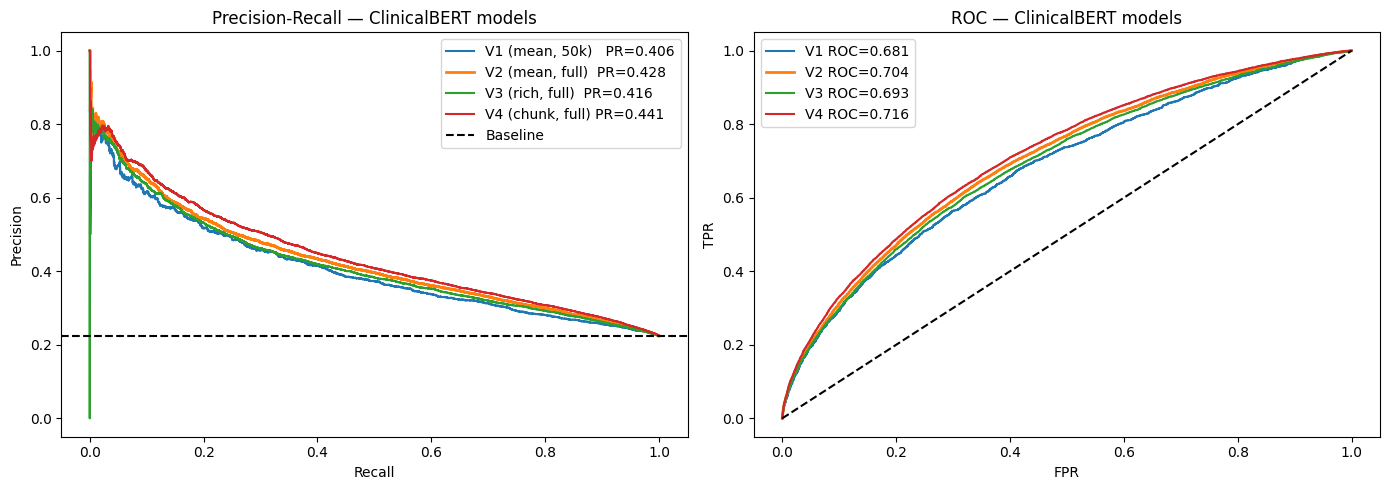


  ClinicalBERT Models — Summary
  V1 (50k,  mean pool,    dense)       ROC 0.681  |  PR 0.406
  V2 (full, mean pool,    attention)   ROC 0.704  |  PR 0.428  ★ best
  V3 (full, CLS+mean+max, attention)   ROC 0.693  |  PR 0.416
  V4 (full, chunked,      attention)   ROC 0.716  |  PR 0.441


In [ ]:
# -- training curves and PR curves for all ClinicalBERT models --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC-PR curves (test set)
axes[0].plot(rec_cb1, prec_cb1, label=f'V1 (mean, 50k)   PR={pr_auc_cb1:.3f}')
axes[0].plot(rec_cb2, prec_cb2, label=f'V2 (mean, full)  PR={pr_auc_cb2:.3f}', linewidth=2)
axes[0].plot(rec_cb3, prec_cb3, label=f'V3 (rich, full)  PR={pr_auc_cb3:.3f}')
if HAS_CHUNKED:
    axes[0].plot(rec_cb4, prec_cb4, label=f'V4 (chunk, full) PR={pr_auc_cb4:.3f}')
axes[0].axhline(y_test_cb2.mean(), color='k', linestyle='--', label='Baseline')
axes[0].set_title('Precision-Recall — ClinicalBERT models')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].legend()

# ROC curves
axes[1].plot(fpr_cb1, tpr_cb1, label=f'V1 ROC={roc_auc_cb1:.3f}')
axes[1].plot(fpr_cb2, tpr_cb2, label=f'V2 ROC={roc_auc_cb2:.3f}', linewidth=2)
axes[1].plot(fpr_cb3, tpr_cb3, label=f'V3 ROC={roc_auc_cb3:.3f}')
if HAS_CHUNKED:
    axes[1].plot(fpr_cb4, tpr_cb4, label=f'V4 ROC={roc_auc_cb4:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC — ClinicalBERT models')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('  ClinicalBERT Models — Summary')
print('='*60)
print(f'  V1 (50k,  mean pool,    dense)       ROC {roc_auc_cb1:.3f}  |  PR {pr_auc_cb1:.3f}')
print(f'  V2 (full, mean pool,    attention)   ROC {roc_auc_cb2:.3f}  |  PR {pr_auc_cb2:.3f}  ★ best')
print(f'  V3 (full, CLS+mean+max, attention)   ROC {roc_auc_cb3:.3f}  |  PR {pr_auc_cb3:.3f}')
if HAS_CHUNKED:
    print(f'  V4 (full, chunked,      attention)   ROC {roc_auc_cb4:.3f}  |  PR {pr_auc_cb4:.3f}')
print('='*60)

## RoBERTa Multimodal Model

RoBERTa (`roberta-base`) is a general-purpose transformer that improves on BERT through optimized pretraining. It sits between SBERT and ClinicalBERT in our encoder lineup: larger and more expressive than SBERT, but without ClinicalBERT's domain adaptation. Including it provides a fair three-way comparison — same architecture, three different encoder families — that isolates the contribution of domain pretraining specifically.

We follow the same pre-compute-once pattern used for ClinicalBERT: a single pass over the dataset to extract [CLS] embeddings, persisted to memory, then a lightweight dense classifier head trained on the cached representations. This optimization reduces training time from hours to minutes per epoch and makes hyperparameter exploration practical.

| Component | Choice | Why |
|---|---|---|
| Text encoder | RoBERTa-base (`keras_hub`) | General-domain comparison vs. ClinicalBERT |
| Pooling | CLS token (first position) | Same as original Kai design |
| Sample size | 50k (configurable) | Matches V1 baseline; fast iteration |
| Training | Frozen backbone + dense head | 60×+ speedup over end-to-end training |
| Class handling | `class_weight={0:1, 1:3}` | Same as original — readmissions ~15-20% |



### Setup

In [ ]:
# -- config --
SAMPLE_SIZE   = 50_000           # set to None to use the full ~94k cohort
SAMPLE_SEED   = 42
SEQ_LEN       = 512              # RoBERTa max sequence length
BATCH_ENCODE  = 32               # batch size for the one-time embedding pass

### Data preparation

Reuses `df_full` (the index-reset full cohort created in cell 90 for the ClinicalBERT models). The purpose of this model is to work on a **50k stratified sample** rather than the full ~94k cohort. The original notebook ran on the full dataset and took roughly **10 hours** to complete training, which made iteration on the architecture impractical. Every change meant another overnight run. Cutting down to 50k preserves enough signal to compare the RoBERTa encoder against the team's SBERT and ClinicalBERT pipelines (V1 also uses 50k, so the comparison stays apples to apples), while bringing total runtime down to a manageable window. Same train/test split logic, same stratification, same structured-feature scaling as ClinicalBERT V1, only the sample size and text encoder differ.

In [ ]:
# -- 50k stratified sample, aligned the same way as ClinicalBERT V1 --
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df_full):
    df_sample_kai = df_full.sample(n=SAMPLE_SIZE, random_state=SAMPLE_SEED)
else:
    df_sample_kai = df_full

print(f'Sample size: {len(df_sample_kai):,}')
print(f'Readmission rate: {df_sample_kai["readmitted_30d"].mean():.3f}')

y_kai        = df_sample_kai['readmitted_30d'].values
X_text_kai   = df_sample_kai['discharge_text'].fillna('').tolist()
X_struct_kai = df_sample_kai.drop(
    columns=['readmitted_30d', 'discharge_text', 'text_length'],
    errors='ignore'
).values.astype('float32')

print(f'Structured features: {X_struct_kai.shape[1]}')

Sample size: 50,000
Readmission rate: 0.224
Structured features: 52


In [ ]:
# -- train/test split (stratified, same seed as team's other models) --
(X_struct_train_kai, X_struct_test_kai,
 X_text_train_kai,   X_text_test_kai,
 y_train_kai,        y_test_kai,
 idx_train_kai,      idx_test_kai) = train_test_split(
    X_struct_kai, X_text_kai, y_kai, np.arange(len(y_kai)),
    test_size=0.2, random_state=SAMPLE_SEED, stratify=y_kai
)

# scale structured features
scaler_kai = StandardScaler()
X_struct_train_kai = scaler_kai.fit_transform(X_struct_train_kai).astype('float32')
X_struct_test_kai  = scaler_kai.transform(X_struct_test_kai).astype('float32')

# class weights (handles ~15-20% readmission imbalance)
weights_kai = compute_class_weight(class_weight='balanced',
                                    classes=np.array([0, 1]), y=y_train_kai)
class_weights_kai = dict(zip([0, 1], weights_kai))

print(f'Train: {len(y_train_kai):,}  |  Test: {len(y_test_kai):,}')
print(f'Class weights: {class_weights_kai}')

Train: 40,000  |  Test: 10,000
Class weights: {0: np.float64(0.644433703882713), 1: np.float64(2.230897936419409)}


### Pre-compute RoBERTa embeddings (one-time)

This is **the optimization**. Rather than running RoBERTa's 125M-parameter forward pass on every batch of every epoch (the bottleneck in the original notebook), we run it exactly once and cache the resulting 768-dim CLS embeddings. The downstream dense head trains on these vectors in seconds per epoch.

The cache is stored on the same GCS bucket as the team's ClinicalBERT embeddings, so re-running the notebook reuses cached vectors instead of recomputing them.

In [ ]:
# -- load RoBERTa backbone + tokenizer (frozen — we only need forward passes) --
tokenizer_roberta = keras_hub.models.Tokenizer.from_preset('roberta_base_en')
backbone_roberta  = keras_hub.models.Backbone.from_preset('roberta_base_en')
backbone_roberta.trainable = False

# packer turns raw text into (token_ids, padding_mask) pairs
packer_roberta = keras_hub.layers.StartEndPacker(
    sequence_length=SEQ_LEN,
    start_value=tokenizer_roberta.start_token_id,
    end_value=tokenizer_roberta.end_token_id,
    pad_value=tokenizer_roberta.pad_token_id,
    return_padding_mask=True,
)

print(f'RoBERTa-base loaded — {backbone_roberta.count_params():,} parameters (frozen)')

RoBERTa-base loaded — 124,052,736 parameters (frozen)


In [ ]:
# -- one-time embedding pass with GCS caching --
fs = gcsfs.GCSFileSystem()
BUCKET   = 'ba865-t9-mimiciv'
CACHE_KEY = f'parquet/roberta_cls_n{len(df_sample_kai)}_seed{SAMPLE_SEED}.npy'
CACHE_PATH = f'gs://{BUCKET}/{CACHE_KEY}'

def encode_texts_roberta(texts, batch_size=BATCH_ENCODE):
    """Run RoBERTa once over all texts, return (n, 768) CLS embeddings."""
    embs = []
    n = len(texts)
    for start in range(0, n, batch_size):
        batch = texts[start:start + batch_size]
        token_ids, padding_mask = packer_roberta(tokenizer_roberta(tf.constant(batch)))
        out = backbone_roberta({'token_ids': token_ids, 'padding_mask': padding_mask},
                                training=False)
        # CLS token = first position = document-level embedding (same as original Kai notebook)
        cls = out[:, 0, :].numpy()
        embs.append(cls)
        if (start // batch_size) % 25 == 0:
            print(f'  {start + len(batch):>6,} / {n:,} encoded')
    return np.vstack(embs).astype('float32')

# split embeddings using the same indices as the train/test split above
X_emb_train_kai = emb_all_kai[idx_train_kai]
X_emb_test_kai  = emb_all_kai[idx_test_kai]
print(f'Train emb: {X_emb_train_kai.shape}  |  Test emb: {X_emb_test_kai.shape}')

Cache miss — encoding 50,000 notes (one-time, ~10-15 min on GPU)
      32 / 50,000 encoded
     832 / 50,000 encoded
   1,632 / 50,000 encoded
   2,432 / 50,000 encoded
   3,232 / 50,000 encoded
   4,032 / 50,000 encoded
   4,832 / 50,000 encoded
   5,632 / 50,000 encoded
   6,432 / 50,000 encoded
   7,232 / 50,000 encoded
   8,032 / 50,000 encoded
   8,832 / 50,000 encoded
   9,632 / 50,000 encoded
  10,432 / 50,000 encoded
  11,232 / 50,000 encoded
  12,032 / 50,000 encoded
  12,832 / 50,000 encoded
  13,632 / 50,000 encoded
  14,432 / 50,000 encoded
  15,232 / 50,000 encoded
  16,032 / 50,000 encoded
  16,832 / 50,000 encoded
  17,632 / 50,000 encoded
  18,432 / 50,000 encoded
  19,232 / 50,000 encoded
  20,032 / 50,000 encoded
  20,832 / 50,000 encoded
  21,632 / 50,000 encoded
  22,432 / 50,000 encoded
  23,232 / 50,000 encoded
  24,032 / 50,000 encoded
  24,832 / 50,000 encoded
  25,632 / 50,000 encoded
  26,432 / 50,000 encoded
  27,232 / 50,000 encoded
  28,032 / 50,000 encoded

### Multimodal model

Same architecture as the original Kai notebook (text branch + structured branch concatenated) but the text branch now consumes the pre-computed 768-dim embedding instead of running RoBERTa from scratch each step. The trainable parameter count drops from ~125M to a few hundred thousand.

In [ ]:
# -- text branch (operates on pre-computed RoBERTa CLS embeddings) --
text_input_kai = layers.Input(shape=(emb_all_kai.shape[1],), name='roberta_emb')
xt = layers.Dropout(0.1)(text_input_kai)
xt = layers.Dense(256, activation='relu')(xt)
xt = layers.Dropout(0.1)(xt)

# -- structured branch (same as original Kai notebook) --
struct_input_kai = layers.Input(shape=(X_struct_train_kai.shape[1],), name='structured')
xs = layers.Dense(64, activation='relu')(struct_input_kai)
xs = layers.Dense(32, activation='relu')(xs)

# -- merge --
merged_kai = layers.Concatenate()([xt, xs])
xm = layers.Dense(64, activation='relu')(merged_kai)
xm = layers.Dropout(0.2)(xm)
out_kai = layers.Dense(1, activation='sigmoid')(xm)

model_kai = keras.Model(
    inputs=[text_input_kai, struct_input_kai],
    outputs=out_kai,
    name='roberta_multimodal'
)

model_kai.compile(
    optimizer=keras.optimizers.Adam(1e-3),  # higher LR ok — only training the head
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.AUC(name='auc_pr', curve='PR')]
)

model_kai.summary()

Model: "roberta_multimodal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ roberta_emb         │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_52          │ (None, 768)       │          0 │ roberta_emb[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ structured          │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 256)       │    196,864 │ dropout_52[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 64)        │      3,392 │ structured[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_53          │ (None, 256)       │          0 │ dense_44[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 32)        │      2,080 │ dense_45[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 288)       │          0 │ dropout_53[0][0], │
│ (Concatenate)       │                   │            │ dense_46[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 64)        │     18,496 │ concatenate_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_54          │ (None, 64)        │          0 │ dense_47[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 1)         │         65 │ dropout_54[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 220,897 (862.88 KB)

 Trainable params: 220,897 (862.88 KB)

 Non-trainable params: 0 (0.00 B)

### Train

With pre-computed embeddings, each epoch processes only the small dense head — under a minute per epoch on a 50k sample even on CPU.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks_kai = [
    EarlyStopping(monitor='val_auc_pr', patience=5, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc_pr', factor=0.5, patience=3,
                      mode='max', verbose=1)
]

history_kai = model_kai.fit(
    [X_emb_train_kai, X_struct_train_kai], y_train_kai,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weights_kai,
    callbacks=callbacks_kai,
    verbose=1
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6217 - auc: 0.6354 - auc_pr: 0.3486 - loss: 0.6640 - val_accuracy: 0.6378 - val_auc: 0.6703 - val_auc_pr: 0.3807 - val_loss: 0.6628 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6453 - auc: 0.6701 - auc_pr: 0.3834 - loss: 0.6486 - val_accuracy: 0.6025 - val_auc: 0.6719 - val_auc_pr: 0.3872 - val_loss: 0.6683 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6437 - auc: 0.6758 - auc_pr: 0.3934 - loss: 0.6446 - val_accuracy: 0.6817 - val_auc: 0.6754 - val_auc_pr: 0.3906 - val_loss: 0.6235 - learning_rate: 0.0010
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6551 - auc: 0.6823 - auc_pr: 0.4036 - loss: 0.6407 - val_accuracy: 0.6699 - val_auc: 0.6780 - val_auc_pr: 0.3968 - val_loss: 0.6260 - learning_rate: 0.0010
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6586 - auc: 0.6879 - auc_pr: 0.4090 - loss: 0.

### Evaluation

In [ ]:
# -- predict on test set --
y_prob_kai = model_kai.predict([X_emb_test_kai, X_struct_test_kai], verbose=0).ravel()
y_pred_kai = (y_prob_kai > 0.5).astype(int)

fpr_kai, tpr_kai, _   = roc_curve(y_test_kai, y_prob_kai)
prec_kai, rec_kai, _  = precision_recall_curve(y_test_kai, y_prob_kai)
roc_auc_kai = auc(fpr_kai, tpr_kai)
pr_auc_kai  = auc(rec_kai, prec_kai)

print(f'RoBERTa Multimodal (Kai) — ROC AUC: {roc_auc_kai:.4f}  |  PR AUC: {pr_auc_kai:.4f}\n')
print(classification_report(y_test_kai, y_pred_kai,
                             target_names=['Not Readmitted', 'Readmitted']))

RoBERTa Multimodal (Kai) — ROC AUC: 0.6744  |  PR AUC: 0.3992

                precision    recall  f1-score   support

Not Readmitted       0.87      0.50      0.64      7759
    Readmitted       0.30      0.73      0.42      2241

      accuracy                           0.55     10000
     macro avg       0.58      0.62      0.53     10000
  weighted avg       0.74      0.55      0.59     10000



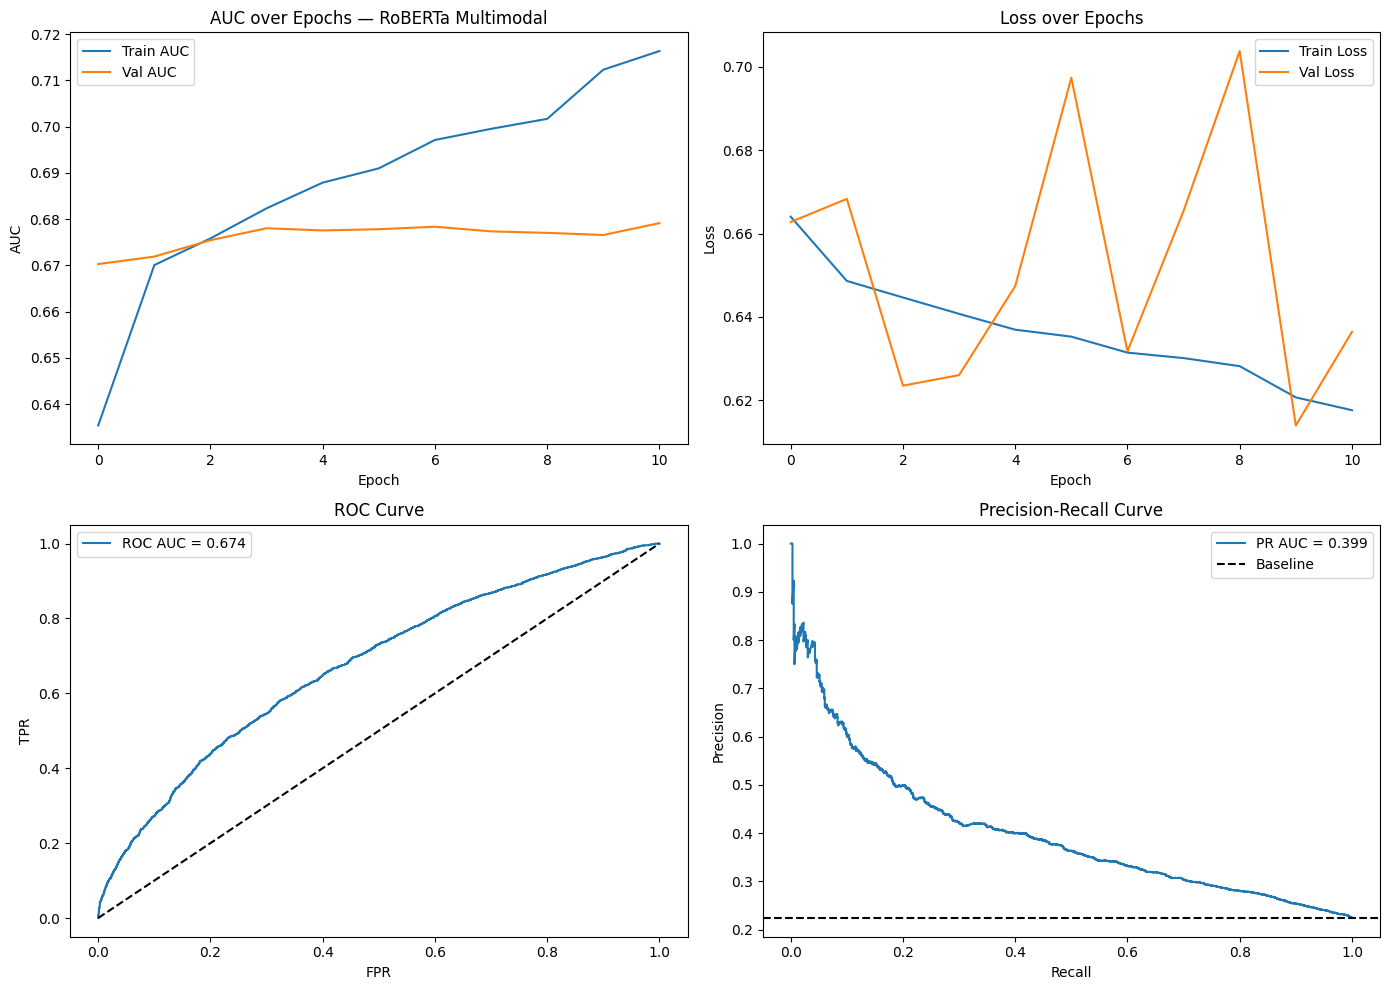

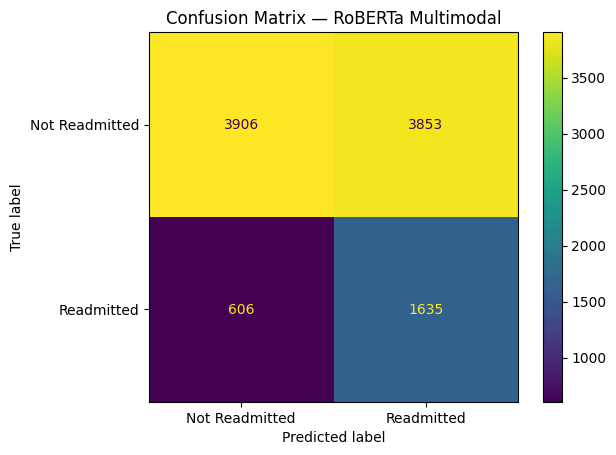

In [ ]:
# -- training curves, ROC, PR, confusion matrix --
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# AUC over epochs
axes[0, 0].plot(history_kai.history['auc'],     label='Train AUC')
axes[0, 0].plot(history_kai.history['val_auc'], label='Val AUC')
axes[0, 0].set_title('AUC over Epochs — RoBERTa Multimodal')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('AUC')
axes[0, 0].legend()

# Loss
axes[0, 1].plot(history_kai.history['loss'],     label='Train Loss')
axes[0, 1].plot(history_kai.history['val_loss'], label='Val Loss')
axes[0, 1].set_title('Loss over Epochs')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# ROC
axes[1, 0].plot(fpr_kai, tpr_kai, label=f'ROC AUC = {roc_auc_kai:.3f}')
axes[1, 0].plot([0, 1], [0, 1], 'k--')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].set_xlabel('FPR'); axes[1, 0].set_ylabel('TPR')
axes[1, 0].legend()

# PR
axes[1, 1].plot(rec_kai, prec_kai, label=f'PR AUC = {pr_auc_kai:.3f}')
axes[1, 1].axhline(y_test_kai.mean(), linestyle='--', color='k', label='Baseline')
axes[1, 1].set_title('Precision-Recall Curve')
axes[1, 1].set_xlabel('Recall'); axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Confusion matrix
cm_kai = confusion_matrix(y_test_kai, y_pred_kai)
ConfusionMatrixDisplay(cm_kai,
                        display_labels=['Not Readmitted', 'Readmitted']).plot()
plt.title('Confusion Matrix — RoBERTa Multimodal')
plt.show()

### Comparison: text encoder family

The three-way comparison isolates the effect of the text encoder while holding the multimodal architecture and training setup fixed. Any performance gap is therefore attributable to the encoder itself (training corpus, vocabulary, and representation quality) rather than downstream design choices.

In [ ]:
# -- compare RoBERTa to ClinicalBERT V1 (closest comparable: same 50k sample, dense head) --
print('=' * 70)
print('  Text encoder comparison — 50k sample, dense head + structured features')
print('=' * 70)
try:
    print(f'  SBERT (MiniLM-L6, 384d)    ROC AUC ~ see Models 1-5 above')
    print(f'  ClinicalBERT V1 (mean, 768d)   ROC {roc_auc_cb1:.3f}  |  PR {pr_auc_cb1:.3f}')
except NameError:
    pass
print(f'  RoBERTa-base (CLS, 768d)       ROC {roc_auc_kai:.3f}  |  PR {pr_auc_kai:.3f}')
print('=' * 70)

  Text encoder comparison — 50k sample, dense head + structured features
  SBERT (MiniLM-L6, 384d)    ROC AUC ~ see Models 1-5 above
  ClinicalBERT V1 (mean, 768d)   ROC 0.681  |  PR 0.406
  RoBERTa-base (CLS, 768d)       ROC 0.674  |  PR 0.399


  Final comparison — best model per text-encoder family
                          Model  Test size  ROC AUC  PR AUC  Precision  Recall     F1
      SBERT (chunk + attention)      10000   0.6811  0.4069     0.3527  0.5538 0.4309
ClinicalBERT V4 (chunked, full)      54569   0.7156  0.4408     0.3541  0.6563 0.4600
             RoBERTa (CLS, 50k)      10000   0.6744  0.3994     0.2979  0.7296 0.4231


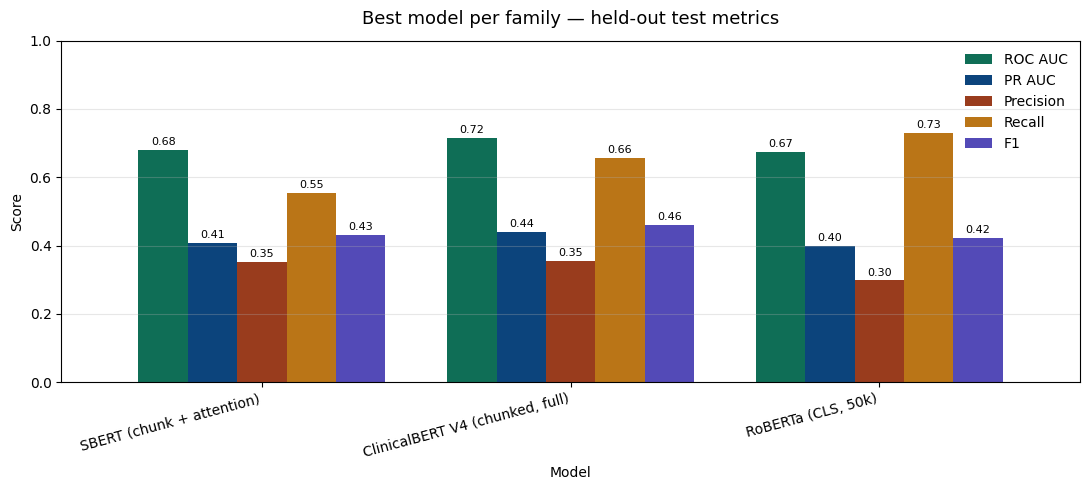

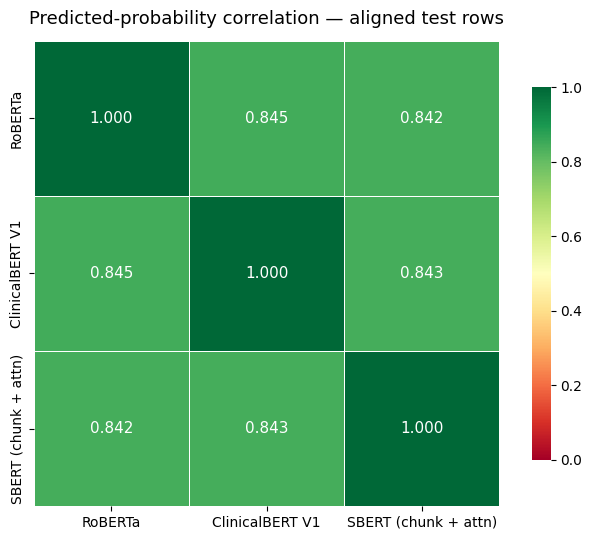

In [ ]:

sbert_y_true = y_test
sbert_y_prob = y_pred_prob.ravel()

# ClinicalBERT — pick the best variant available
# (V4 chunked > V2/V3 full > V1 50k sample by AUC)
if 'roc_auc_cb4' in globals() and roc_auc_cb4 is not None:
    cbert_label  = 'ClinicalBERT V4 (chunked, full)'
    cbert_y_true = y_test_cb4
    cbert_y_prob = y_prob_cb4.ravel() if 'y_prob_cb4' in globals() else model_cb4.predict(
        [X_struct_test_cb4, X_emb_test_cb4], verbose=0
    ).ravel()
elif 'roc_auc_cb2' in globals():
    cbert_label  = 'ClinicalBERT V2 (mean, full)'
    cbert_y_true = y_test_cb2
    cbert_y_prob = y_prob_cb2.ravel() if 'y_prob_cb2' in globals() else model_cb2.predict(
        [X_struct_test_cb2, X_emb_test_cb2], verbose=0
    ).ravel()
else:
    cbert_label  = 'ClinicalBERT V1 (mean, 50k)'
    cbert_y_true = y_test_cb1
    cbert_y_prob = model_cb1.predict(X_test_cb1, verbose=0).ravel()

# RoBERTa
rob_y_true = y_test_kai
rob_y_prob = y_prob_kai.ravel()

# headline metrics table
def metrics_row(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    return {
        'Model'    : name,
        'Test size': len(y_true),
        'ROC AUC'  : roc_auc_score(y_true, y_prob),
        'PR AUC'   : average_precision_score(y_true, y_prob),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
    }

results_df = pd.DataFrame([
    metrics_row('SBERT (chunk + attention)', sbert_y_true, sbert_y_prob),
    metrics_row(cbert_label,                 cbert_y_true, cbert_y_prob),
    metrics_row('RoBERTa (CLS, 50k)',        rob_y_true,   rob_y_prob),
]).round(4)

print('=' * 78)
print('  Final comparison — best model per text-encoder family')
print('=' * 78)
print(results_df.to_string(index=False))
print('=' * 78)


# bar chart of headline metrics
metric_cols = ['ROC AUC', 'PR AUC', 'Precision', 'Recall', 'F1']
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = results_df.set_index('Model')[metric_cols]
plot_df.plot(kind='bar', ax=ax, width=0.8,
             color=['#0F6E56', '#0C447C', '#993C1D', '#BA7517', '#534AB7'])
ax.set_title('Best model per family — held-out test metrics', fontsize=13, pad=12)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.0)
ax.set_xticklabels(plot_df.index, rotation=15, ha='right')
ax.legend(loc='upper right', frameon=False)
ax.grid(axis='y', alpha=0.3)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout(); plt.show()


# crrelation matrix of predicted probabilities
prob_dict = {}

# RoBERTa is always available
prob_dict['RoBERTa'] = rob_y_prob

# clinicalBERT V1 is the natural match for RoBERTa (same 50k sample, same seed)
if 'model_cb1' in globals():
    cb1_prob = model_cb1.predict(X_test_cb1, verbose=0).ravel()
    if len(cb1_prob) == len(rob_y_prob):
        prob_dict['ClinicalBERT V1'] = cb1_prob

# best ClinicalBERT
if len(cbert_y_prob) == len(rob_y_prob):
    prob_dict[cbert_label] = cbert_y_prob

# SBERT only if shapes line up (typically a 10k subsample - won't match)
if len(sbert_y_prob) == len(rob_y_prob):
    prob_dict['SBERT (chunk + attn)'] = sbert_y_prob

if len(prob_dict) >= 2:
    corr_df = pd.DataFrame(prob_dict)
    corr_matrix = corr_df.corr()

    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.0, vmax=1.0, square=True, cbar_kws={'shrink': 0.8},
                annot_kws={'size': 11}, linewidths=0.5, ax=ax)
    ax.set_title('Predicted-probability correlation — aligned test rows',
                 fontsize=13, pad=12)
    plt.tight_layout(); plt.show()



## Future work and suggestions

While our best model (ClinicalBERT V2) achieves ROC AUC 0.704 and PR AUC 0.429, several directions could push performance further:

**Architectural improvements**
- **Fine-tune ClinicalBERT end-to-end** instead of using frozen embeddings. This would let the encoder adapt its representations specifically to readmission prediction rather than relying on its pretraining objective. Resource-intensive (requires A100+ and gradient checkpointing) but the most likely path to a meaningful gain.
- **Hierarchical attention over note sections.** Discharge notes have implicit structure (HPI, hospital course, discharge plan, follow-up). Section-aware attention could weight clinically critical sections (e.g., discharge condition, follow-up instructions) more heavily.
- **Imprement cross-attention** to allow the model to learn in paralel from structured features and text embeddings and potentially mapping the discharge reasoning with the observed numeric and categorical variables.  

**Feature engineering**
- **Temporal features** beyond `prior_admissions`: time since last admission, frequency of admissions over time windows, seasonal patterns.
- **Interaction features** between `prior_admissions` and clinical risk indicators, since permutation importance showed `prior_admissions` dominates the structured signal.
- **Medication and procedure codes** from MIMIC's other tables — currently unused.

**Training and evaluation**
- **Subgroup performance analysis** by age, gender, insurance, and ICD chapter to surface fairness or generalization concerns.
- **Cross-validation** instead of a single train/test split, for more robust performance estimates.

**Beyond performance**
- **Explainability:** integrate SHAP or attention-weight visualization to surface which patient factors drive each prediction — critical for any real clinical deployment.
- **External validation** on a different hospital system to test whether the model generalizes beyond MIMIC.